# Проект: Анализ пространственно-временной динамики ареала лебедей в Северной Америке

---

Выполнила: *Мартынова Наталья*

Дата: *сентябрь 2026 г.*

---

## Цель проекта

Определить, наблюдается ли статистически значимое смещение ареала лебедей в Северной Америке, и выявить, различается ли это смещение в разных географических зонах. Оценить влияние внешних факторов (температура, плотность населения) на пространственное распределение птиц.

---

## Задачи проекта

1. Загрузить и очистить данные о наблюдениях за лебедями.
2. Добавить внешние данные (плотность населения и температура по штатам и провинциям).
3. Провести кластерный анализ для выделения географических зон.
4. Учесть сезонность и другие искажающие факторы.
5. Провести статистический анализ: оценить тренды, сравнить виды и сезоны.
6. Построить визуализации (не менее 4 графиков).
7. Сформулировать выводы.

---

## Данные

Данные представлены в виде 4-х файлов: 

- `short.csv` - Наблюдения за лебедями (6 видов, 1980–2024) - ~3.5 млн записей
- `US_CA.csv` - Плотность населения штатов США и провинций Канады - 69 записей
- `us_state_temperatures.csv` - Среднемесячные температуры по штатам США - ~26 868 записей
- `canada_temperatures.csv` - Среднемесячные температуры по провинциям Канады - 6 864 записи

Источник: GBIF (Global Biodiversity Information Facility)

---

## 1. Загрузка библиотек

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress, kruskal, mannwhitneyu, pearsonr, spearmanr
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.formula.api import ols
from itertools import combinations
from statsmodels.stats.multitest import multipletests 
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.gridspec as gridspec

sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

## 2. Загрузка данных

In [2]:
data = pd.read_csv('short.csv')
data.info()
print(data.shape)
print(data.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3489498 entries, 0 to 3489497
Data columns (total 22 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   gbifID                         int64  
 1   basisOfRecord                  object 
 2   recordedBy                     object 
 3   eventDate                      object 
 4   year                           int64  
 5   month                          int64  
 6   day                            int64  
 7   countryCode                    object 
 8   stateProvince                  object 
 9   locality                       object 
 10  decimalLatitude                float64
 11  decimalLongitude               float64
 12  coordinateUncertaintyInMeters  float64
 13  coordinatePrecision            float64
 14  infraspecificEpithet           float64
 15  taxonRank                      object 
 16  datasetKey                     object 
 17  elevation                      float64
 18  el

Набор данных состоит из 3 489 498 строк и 22 столбцов. Представляет собой реестр наблюдений за биоразнообразием с информацией о видах, датах и географических координатах. Анализ полноты показывает, что 14 столбцов (включая ключевые идентификаторы, таксономию и широту/долготу) не имеют пропусков, а в поле `locality` отсутствует всего 4 значения. При этом 7 числовых столбцов, отвечающих за метрики точности координат, высоту и глубину (например, `coordinateUncertaintyInMeters`, `elevation`, `depth`), а также поле `infraspecificEpithet`, содержат 100% пропусков (ровно 3 489 498 отсутствующих значений) и подлежат удалению на этапе предобработки в силу полного отсутствия информационной ценности.

## 3. Удаление пустых столбцов

> TODO: удалите столбцы, полностью состоящие из пропусков, и столбец `locality`.

In [3]:
# Удаляем из датасета data 8 столбцов: locality, coordinateUncertaintyInMeters, coordinatePrecision, infraspecificEpithet,
# elevation, elevationAccuracy, depth, depthAccuracy
data = data.drop(columns=['locality', 'coordinateUncertaintyInMeters', 'coordinatePrecision', 'infraspecificEpithet', 'elevation', 'elevationAccuracy', 'depth', 'depthAccuracy'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3489498 entries, 0 to 3489497
Data columns (total 14 columns):
 #   Column            Dtype  
---  ------            -----  
 0   gbifID            int64  
 1   basisOfRecord     object 
 2   recordedBy        object 
 3   eventDate         object 
 4   year              int64  
 5   month             int64  
 6   day               int64  
 7   countryCode       object 
 8   stateProvince     object 
 9   decimalLatitude   float64
 10  decimalLongitude  float64
 11  taxonRank         object 
 12  datasetKey        object 
 13  species           object 
dtypes: float64(2), int64(4), object(8)
memory usage: 372.7+ MB


In [4]:
data.isna().sum()

gbifID              0
basisOfRecord       0
recordedBy          0
eventDate           0
year                0
month               0
day                 0
countryCode         0
stateProvince       0
decimalLatitude     0
decimalLongitude    0
taxonRank           0
datasetKey          0
species             0
dtype: int64

Удаление 8-ми столбцов прошло успешно. В датасете осталось 14 столбцов без пропусков.

## 4. Переименование столбцов в snake_case

> TODO: примените функцию `camel_to_snake` ко всем столбцам.

In [5]:
# Названия столбцов до переименования
data.columns

Index(['gbifID', 'basisOfRecord', 'recordedBy', 'eventDate', 'year', 'month',
       'day', 'countryCode', 'stateProvince', 'decimalLatitude',
       'decimalLongitude', 'taxonRank', 'datasetKey', 'species'],
      dtype='object')

In [6]:
def camel_to_snake(name):
    '''Преобразует CamelCase в snake_case.'''
    s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    return re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1).lower()

In [7]:
# Применим функцию camel_to_snake() к столбцам датасета
data.columns = [camel_to_snake(col) for col in data.columns]

# Названия столбцов после переименования
data.columns

Index(['gbif_id', 'basis_of_record', 'recorded_by', 'event_date', 'year',
       'month', 'day', 'country_code', 'state_province', 'decimal_latitude',
       'decimal_longitude', 'taxon_rank', 'dataset_key', 'species'],
      dtype='object')

Переименование столбцов датасета прошло успешно.

## 5. Преобразование типа event_date

> TODO: приведите `event_date` к `datetime`.

In [8]:
# Преобразуем тип данных в столбце event_date к datetime
data['event_date'] = pd.to_datetime(data['event_date'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3489498 entries, 0 to 3489497
Data columns (total 14 columns):
 #   Column             Dtype         
---  ------             -----         
 0   gbif_id            int64         
 1   basis_of_record    object        
 2   recorded_by        object        
 3   event_date         datetime64[ns]
 4   year               int64         
 5   month              int64         
 6   day                int64         
 7   country_code       object        
 8   state_province     object        
 9   decimal_latitude   float64       
 10  decimal_longitude  float64       
 11  taxon_rank         object        
 12  dataset_key        object        
 13  species            object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(7)
memory usage: 372.7+ MB


Преобразование типа прошло успешно.

## 6. Фильтрация данных

> TODO:
> - оставить только три вида: `Cygnus olor`, `Cygnus buccinator`, `Cygnus columbianus`;
> - оставить только US и CA;
> - ограничить координаты (широта 25–75°, долгота −170…−35°);
> - удалить столбцы с единственным уникальным значением.

In [9]:
data.head()

,gbif_id,basis_of_record,recorded_by,event_date,year,month,day,country_code,state_province,decimal_latitude,decimal_longitude,taxon_rank,dataset_key,species
0,938888072,HUMAN_OBSERVATION,obsr137539,2008-01-19,2008,1,19,US,Massachusetts,42.041756,-70.193480,SPECIES,4fa7b334-ce0d-4e88-aaae-2e0c138d049e,Cygnus olor
1,3511818940,HUMAN_OBSERVATION,obsr902368,2021-01-23,2021,1,23,US,Massachusetts,42.222797,-72.608850,SPECIES,4fa7b334-ce0d-4e88-aaae-2e0c138d049e,Cygnus olor
2,5474067204,HUMAN_OBSERVATION,obsr440493,2024-03-21,2024,3,21,US,New York,40.953114,-73.701225,SPECIES,4fa7b334-ce0d-4e88-aaae-2e0c138d049e,Cygnus olor
3,3264353040,HUMAN_OBSERVATION,obsr305952,2020-05-28,2020,5,28,CA,Ontario,43.231647,-81.911110,SPECIES,4fa7b334-ce0d-4e88-aaae-2e0c138d049e,Cygnus olor
4,3630533474,HUMAN_OBSERVATION,obsr1312860,2021-09-09,2021,9,9,CA,Ontario,43.155900,-79.176960,SPECIES,4fa7b334-ce0d-4e88-aaae-2e0c138d049e,Cygnus buccinator


In [10]:
# Отфильтруем датасет по видам лебедей
data_filt = data[(data['species'] == 'Cygnus olor') | (data['species'] == 'Cygnus buccinator') | (data['species'] == 'Cygnus columbianus')]
data_filt['species'].unique()

array(['Cygnus olor', 'Cygnus buccinator', 'Cygnus columbianus'],
      dtype=object)

In [11]:
# Отфильтруем датасет по коду страны
data_filt = data_filt[(data_filt['country_code'] == 'US') | (data_filt['country_code'] == 'CA')]
data_filt['country_code'].unique()

array(['US', 'CA'], dtype=object)

In [12]:
# Отфильтруем датасет по координатам
data_filt = data_filt[(data_filt['decimal_latitude'] > 25) & (data_filt['decimal_latitude'] < 75) & (data_filt['decimal_longitude'] > -170) & (data_filt['decimal_longitude'] < -35)]
data_filt['decimal_latitude'].describe()

count    3.477414e+06
mean     4.299562e+01
std      4.558215e+00
min      2.525389e+01
25%      4.074377e+01
50%      4.239741e+01
75%      4.403759e+01
max      7.428330e+01
Name: decimal_latitude, dtype: float64

In [13]:
data_filt['decimal_longitude'].describe()

count    3.477414e+06
mean    -8.753679e+01
std      1.798211e+01
min     -1.696069e+02
25%     -9.092027e+01
50%     -8.152811e+01
75%     -7.526015e+01
max     -5.269413e+01
Name: decimal_longitude, dtype: float64

In [14]:
# Проверяем отфильтрованный датасет на число уникальных признаков в столбцах
data_filt.nunique()

gbif_id              3477414
basis_of_record            1
recorded_by           133457
event_date             16041
year                      45
month                     12
day                       31
country_code               2
state_province            62
decimal_latitude      326558
decimal_longitude     331078
taxon_rank                 1
dataset_key                1
species                    3
dtype: int64

In [15]:
# Удалим столбцы с единственным уникальным значением: basis_of_record, taxon_rank, dataset_key
data_filt = data_filt.drop(columns=['basis_of_record', 'taxon_rank', 'dataset_key'])
data_filt.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3477414 entries, 0 to 3489497
Data columns (total 11 columns):
 #   Column             Dtype         
---  ------             -----         
 0   gbif_id            int64         
 1   recorded_by        object        
 2   event_date         datetime64[ns]
 3   year               int64         
 4   month              int64         
 5   day                int64         
 6   country_code       object        
 7   state_province     object        
 8   decimal_latitude   float64       
 9   decimal_longitude  float64       
 10  species            object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(4)
memory usage: 318.4+ MB


В результате фильтрации датасет уменьшился с 3 489 498 до 3 477 414 строк (удалено 12 084 записи, не попавших в заданный географический диапазон) и с 14 до 11 столбцов - были удалены 3 категориальных столбца типа `object`: `basis_of_record`, `taxon_rank` и `dataset_key` (как содержащие единственное уникальное значение после геофильтрации).

## 7. Обрезка по годам

> TODO: оставьте только `year <= 2023`.

In [16]:
# Отфильтруем датасет по годам
data_filt = data_filt[data_filt['event_date'] < '2024-01-01']
data_filt['event_date'].describe()

count                 3033096
unique                  15675
top       2023-05-13 00:00:00
freq                     4816
first     1980-01-01 00:00:00
last      2023-12-31 00:00:00
Name: event_date, dtype: object

In [17]:
data_filt.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3033096 entries, 0 to 3489497
Data columns (total 11 columns):
 #   Column             Dtype         
---  ------             -----         
 0   gbif_id            int64         
 1   recorded_by        object        
 2   event_date         datetime64[ns]
 3   year               int64         
 4   month              int64         
 5   day                int64         
 6   country_code       object        
 7   state_province     object        
 8   decimal_latitude   float64       
 9   decimal_longitude  float64       
 10  species            object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(4)
memory usage: 277.7+ MB


Количество строк уменьшилось с 3 477 414 до 3 033 096 (удалено ровно 444 318 записей, не попавших в заданный временной диапазон).

## 8. Загрузка внешних данных

> TODO:
> - загрузите `US_CA.csv`, `us_state_temperatures.csv`, `canada_temperatures.csv`;
> - приведите названия штатов и провинций к единому виду;
> - приведите датасеты температур к единому формату.

In [18]:
df_US_CA = pd.read_csv('US_CA.csv')
us_temperatures = pd.read_csv('us_state_temperatures.csv')
ca_temperatures = pd.read_csv('canada_temperatures.csv')

In [19]:
# Функция отображения информации о датасете
def info_summary(dataframe):
    display(dataframe.head(5))
    display(dataframe.info())

In [20]:
info_summary(df_US_CA)

,state_province,land_area,density_per
0,District of Columbia,158.0,4297.0
1,New Jersey,19047.0,488.0
2,Rhode Island,2678.0,409.0
3,Puerto Rico,8868.0,361.0
4,Massachusetts,20202.0,347.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   state_province  69 non-null     object 
 1   land_area       69 non-null     float64
 2   density_per     69 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.7+ KB


None

In [21]:
# Выведем все уникальные названия штатов и провинций в df_US_CA до корректировки
sorted(df_US_CA['state_province'].unique())

['AB',
 'Alabama',
 'Alaska',
 'American Samoa[4]',
 'Arizona',
 'Arkansas',
 'British Columbia',
 'California',
 'Colorado',
 'Connecticut',
 'Delaware',
 'District of Columbia',
 'Florida',
 'Georgia',
 'Guam[4]',
 'Hawaii',
 'Idaho',
 'Illinois',
 'Indiana',
 'Iowa',
 'Kansas',
 'Kentucky',
 'Louisiana',
 'Maine',
 'Manitoba',
 'Maryland',
 'Massachusetts',
 'Michigan',
 'Minnesota',
 'Mississippi',
 'Missouri',
 'Montana',
 'Nebraska',
 'Nevada',
 'New Brunswick',
 'New Hampshire',
 'New Jersey',
 'New Mexico',
 'New York',
 'Newfoundland and Labrador',
 'North Carolina',
 'North Dakota',
 'Northern Mariana Islands[4]',
 'Northwest Territories',
 'Nova Scotia',
 'Nunavut',
 'Ohio',
 'Oklahoma',
 'Ontario',
 'Oregon',
 'Pennsylvania',
 'Prince Edward Island',
 'Puerto Rico',
 'Quebec',
 'Rhode Island',
 'Saskatchewan',
 'South Carolina',
 'South Dakota',
 'Tennessee',
 'Texas',
 'U.S. Virgin Islands[4]',
 'Utah',
 'Vermont',
 'Virginia',
 'Washington',
 'West Virginia',
 'Wisconsin'

Для того, чтобы впоследствии мы могли присоединить информацию этого датасета к основной таблице, лучше привести этот столбец к тому же виду, как в data_filt:

In [22]:
sorted(data_filt['state_province'].unique())

['Alabama',
 'Alaska',
 'Alberta',
 'Arizona',
 'Arkansas',
 'British Columbia',
 'California',
 'Colorado',
 'Connecticut',
 'Delaware',
 'District of Columbia',
 'Florida',
 'Georgia',
 'Idaho',
 'Illinois',
 'Indiana',
 'Iowa',
 'Kansas',
 'Kentucky',
 'Louisiana',
 'Maine',
 'Manitoba',
 'Maryland',
 'Massachusetts',
 'Michigan',
 'Minnesota',
 'Mississippi',
 'Missouri',
 'Montana',
 'Nebraska',
 'Nevada',
 'New Brunswick',
 'New Hampshire',
 'New Jersey',
 'New Mexico',
 'New York',
 'Newfoundland and Labrador',
 'North Carolina',
 'North Dakota',
 'Northwest Territories',
 'Nova Scotia',
 'Nunavut',
 'Ohio',
 'Oklahoma',
 'Ontario',
 'Oregon',
 'Pennsylvania',
 'Quebec',
 'Rhode Island',
 'Saskatchewan',
 'South Carolina',
 'South Dakota',
 'Tennessee',
 'Texas',
 'Utah',
 'Vermont',
 'Virginia',
 'Washington',
 'West Virginia',
 'Wisconsin',
 'Wyoming',
 'Yukon Territory']

Для корректного соединения таблиц в будущем необходимо устранить три типа несоответствий в названиях:
1. Артефакты в названиях - суффиксы [4] у территорий США.
2. Аббревиатуры канадских провинций - 'AB' вместо полного названия.
3. Различия в названиях территорий - 'Yukon' vs 'Yukon Territory'.

In [23]:
# Удаляем артефакты вида '[4]', '[12]' и т.д.
df_US_CA['state_province'] = df_US_CA['state_province'].str.replace(r'\[\d+\]', '', regex=True)

In [24]:
# Словарь замен для приведения к формату data_filt
state_rename_map = {
    # Канадские провинции: аббревиатуры и короткие формы → полные названия
    'AB':     'Alberta',
    'Yukon':  'Yukon Territory'}

# Применяем замену
df_US_CA['state_province'] = df_US_CA['state_province'].replace(state_rename_map)

# Выведем все уникальные названия штатов и провинций датасета df_US_CA после корректировки
sorted(df_US_CA['state_province'].unique())

['Alabama',
 'Alaska',
 'Alberta',
 'American Samoa',
 'Arizona',
 'Arkansas',
 'British Columbia',
 'California',
 'Colorado',
 'Connecticut',
 'Delaware',
 'District of Columbia',
 'Florida',
 'Georgia',
 'Guam',
 'Hawaii',
 'Idaho',
 'Illinois',
 'Indiana',
 'Iowa',
 'Kansas',
 'Kentucky',
 'Louisiana',
 'Maine',
 'Manitoba',
 'Maryland',
 'Massachusetts',
 'Michigan',
 'Minnesota',
 'Mississippi',
 'Missouri',
 'Montana',
 'Nebraska',
 'Nevada',
 'New Brunswick',
 'New Hampshire',
 'New Jersey',
 'New Mexico',
 'New York',
 'Newfoundland and Labrador',
 'North Carolina',
 'North Dakota',
 'Northern Mariana Islands',
 'Northwest Territories',
 'Nova Scotia',
 'Nunavut',
 'Ohio',
 'Oklahoma',
 'Ontario',
 'Oregon',
 'Pennsylvania',
 'Prince Edward Island',
 'Puerto Rico',
 'Quebec',
 'Rhode Island',
 'Saskatchewan',
 'South Carolina',
 'South Dakota',
 'Tennessee',
 'Texas',
 'U.S. Virgin Islands',
 'Utah',
 'Vermont',
 'Virginia',
 'Washington',
 'West Virginia',
 'Wisconsin',
 'Wyo

In [25]:
info_summary(us_temperatures)

,state,year,month,avg_temp_f,avg_temp_c
0,Alabama,1980,1,46.7,8.166667
1,Alabama,1980,2,42.7,5.944444
2,Alabama,1980,3,52.6,11.444444
3,Alabama,1980,4,60.6,15.888889
4,Alabama,1980,5,70.2,21.222222


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26868 entries, 0 to 26867
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   state       26868 non-null  object 
 1   year        26868 non-null  int64  
 2   month       26868 non-null  int64  
 3   avg_temp_f  26868 non-null  float64
 4   avg_temp_c  26868 non-null  float64
dtypes: float64(2), int64(2), object(1)
memory usage: 1.0+ MB


None

In [26]:
info_summary(ca_temperatures)

,state_province,year,month,avg_temp_c
0,Alberta,1980,1,-15.833060
1,Alberta,1980,2,-8.911123
2,Alberta,1980,3,-6.203974
3,Alberta,1980,4,7.940524
4,Alberta,1980,5,11.229850


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6864 entries, 0 to 6863
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   state_province  6864 non-null   object 
 1   year            6864 non-null   int64  
 2   month           6864 non-null   int64  
 3   avg_temp_c      6864 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 214.6+ KB


None

Для приведения датасетов с температурами к единому формату, необходимо:

- в us_temperatures название региона исправить на state_province, как во всех остальных таблицах;
- ca_temperatures добавить столбец avg_temp_f с температурой °F.

In [27]:
# Приводим к единому имени колонки штата
us_temperatures = us_temperatures.rename(columns={'state': 'state_province'})

# Рассчитываем недостающую avg_temp_f для Канады
ca_temperatures['avg_temp_f'] = ca_temperatures['avg_temp_c'] * 9 / 5 + 32

# Приводим к единому порядку колонок
columns_order = ['state_province', 'year', 'month', 'avg_temp_c', 'avg_temp_f']
us_temperatures = us_temperatures[columns_order]
ca_temperatures = ca_temperatures[columns_order]

In [28]:
us_temperatures.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26868 entries, 0 to 26867
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   state_province  26868 non-null  object 
 1   year            26868 non-null  int64  
 2   month           26868 non-null  int64  
 3   avg_temp_c      26868 non-null  float64
 4   avg_temp_f      26868 non-null  float64
dtypes: float64(2), int64(2), object(1)
memory usage: 1.0+ MB


In [29]:
ca_temperatures.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6864 entries, 0 to 6863
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   state_province  6864 non-null   object 
 1   year            6864 non-null   int64  
 2   month           6864 non-null   int64  
 3   avg_temp_c      6864 non-null   float64
 4   avg_temp_f      6864 non-null   float64
dtypes: float64(2), int64(2), object(1)
memory usage: 268.2+ KB


In [30]:
# Выведем все уникальные названия штатов и провинций в us_temperatures до корректировки
sorted(us_temperatures['state_province'].unique())

['Alabama',
 'Alaska',
 'Arizona',
 'Arkansas',
 'California',
 'Colorado',
 'Connecticut',
 'Delaware',
 'Florida',
 'Georgia',
 'Hawaii',
 'Idaho',
 'Illinois',
 'Indiana',
 'Iowa',
 'Kansas',
 'Kentucky',
 'Louisiana',
 'Maine',
 'Maryland',
 'Massachusetts',
 'Michigan',
 'Minnesota',
 'Mississippi',
 'Missouri',
 'Montana',
 'Nebraska',
 'Nevada',
 'New_Hampshire',
 'New_Jersey',
 'New_Mexico',
 'New_York',
 'North_Carolina',
 'North_Dakota',
 'Ohio',
 'Oklahoma',
 'Oregon',
 'Pennsylvania',
 'Rhode_Island',
 'South_Carolina',
 'South_Dakota',
 'Tennessee',
 'Texas',
 'Utah',
 'Vermont',
 'Virginia',
 'Washington',
 'West_Virginia',
 'Wisconsin',
 'Wyoming']

Видим, что в названиях из двух слов присутствует знак _, чего нет в основном датасете. Исправим это в us_temperatures:

In [31]:
# Заменяем нижние подчеркивания на пробелы в столбце state
us_temperatures['state_province'] = us_temperatures['state_province'].str.replace('_', ' ')

# Проверяем результат
sorted(us_temperatures['state_province'].unique())

['Alabama',
 'Alaska',
 'Arizona',
 'Arkansas',
 'California',
 'Colorado',
 'Connecticut',
 'Delaware',
 'Florida',
 'Georgia',
 'Hawaii',
 'Idaho',
 'Illinois',
 'Indiana',
 'Iowa',
 'Kansas',
 'Kentucky',
 'Louisiana',
 'Maine',
 'Maryland',
 'Massachusetts',
 'Michigan',
 'Minnesota',
 'Mississippi',
 'Missouri',
 'Montana',
 'Nebraska',
 'Nevada',
 'New Hampshire',
 'New Jersey',
 'New Mexico',
 'New York',
 'North Carolina',
 'North Dakota',
 'Ohio',
 'Oklahoma',
 'Oregon',
 'Pennsylvania',
 'Rhode Island',
 'South Carolina',
 'South Dakota',
 'Tennessee',
 'Texas',
 'Utah',
 'Vermont',
 'Virginia',
 'Washington',
 'West Virginia',
 'Wisconsin',
 'Wyoming']

In [32]:
# Выведем все уникальные названия штатов и провинций в ca_temperatures до корректировки
sorted(ca_temperatures['state_province'].unique())

['Alberta',
 'British Columbia',
 'Manitoba',
 'New Brunswick',
 'Newfoundland and Labrador',
 'Northwest Territories',
 'Nova Scotia',
 'Nunavut',
 'Ontario',
 'Prince Edward Island',
 'Quebec',
 'Saskatchewan',
 'Yukon Territory']

Дополнительная очистка или исправление опечаток в названиях регионов Канады перед объединением не требуется.

## 9. Сезонная фильтрация

> TODO:
> - оставьте только декабрь, январь, февраль и июнь, июль, август;
> - создайте столбец `period_type` (1 = зимовка, 2 = гнездование).

In [33]:
# Функция назначение категории
def get_period_type(month):
    if month in [12, 1, 2]:
        return 1  # зимовка
    elif month in [6, 7, 8]:
        return 2  # гнездование
    else:
        return None  # другие месяцы

# Применяем функцию к каждой ячейке столбца month
data_filt['period_type'] = data_filt['month'].apply(get_period_type)

# Проверяем результат
data_filt['period_type'].value_counts(dropna=False)

NaN    1743426
1.0     909198
2.0     380472
Name: period_type, dtype: int64

In [34]:
# Отфильтруем периоды вне зимовки и гнездования
data_filt = data_filt[data_filt['period_type'].notna()]
data_filt['period_type'].value_counts(dropna=False)

1.0    909198
2.0    380472
Name: period_type, dtype: int64

Сезонная фильтрация проведена.

## 10. Разбивка на временные периоды

> TODO: создайте столбец `time_period` с 5 интервалами:
> `1_1980-1988`, `2_1989-1997`, `3_1998-2006`, `4_2007-2015`, `5_2016-2023`.

In [35]:
# Функция для категоризации по временным интервалам на основе даты события
def get_time_period(year):
    if 1980 <= year <= 1988:
        return '1_1980-1988'
    elif 1989 <= year <= 1997:
        return '2_1989-1997'
    elif 1998 <= year <= 2006:
        return '3_1998-2006'
    elif 2007 <= year <= 2015:
        return '4_2007-2015'
    elif 2016 <= year <= 2023:
        return '5_2016-2023'
    else:
        return None  # если год за пределами наших интервалов

# Применяем функцию к каждой ячейке столбца year
data_filt['time_period'] = data_filt['year'].apply(get_time_period)

# Проверяем результат
data_filt['time_period'].value_counts(dropna=False)

5_2016-2023    983997
4_2007-2015    251921
3_1998-2006     34526
2_1989-1997     13223
1_1980-1988      6003
Name: time_period, dtype: int64

Столбец с временными интервалами создан. Лет за пределами наших интервалов не было определено функцией.

## 11. Округление координат и удаление дубликатов

> TODO: округлите координаты до целых и удалите дубликаты по набору
> `(year, period_type, decimal_longitude, decimal_latitude, species)`.

In [36]:
# Округляем координаты до целых
data_filt['decimal_latitude'] = data_filt['decimal_latitude'].round()
data_filt['decimal_longitude'] = data_filt['decimal_longitude'].round()

# Проверяем результат
data_filt[['decimal_latitude', 'decimal_longitude']].head(10)

,decimal_latitude,decimal_longitude
0,42.0,-70.0
1,42.0,-73.0
7,43.0,-85.0
8,38.0,-77.0
9,50.0,-117.0
13,44.0,-76.0
20,42.0,-72.0
21,42.0,-72.0
22,39.0,-90.0
25,42.0,-88.0


In [37]:
# Строк до удаления дубликатов
data_filt.shape[0]

1289670

In [38]:
# Удаляем дубликаты по набору (year, period_type, decimal_longitude, decimal_latitude, species)
data_filt = data_filt.drop_duplicates(subset=['year', 'period_type', 'decimal_longitude', 'decimal_latitude', 'species'])

# Строк после удаления дубликатов
data_filt.shape[0]

33095

Округление координат и удаление дубликатов произведено.

## 12. Объединение с температурой

> TODO:
> - объедините датасет с `temperatures_US_CA` по ключу `(state_province, year, month)`;
> - заполните пропуски температуры средним значением по `(state_province, month)`.

In [39]:
# Готовим единый датасет температур
us = us_temperatures.copy()
ca = ca_temperatures.copy()

# Добавляем столбец с признаком страны
us['country'] = 'US'
ca['country'] = 'CA'

temperatures = pd.concat([us, ca], ignore_index=True)

# Проверяем, что нет дубликатов по ключам соединения
dup_count = temperatures.duplicated(subset=['state_province', 'year', 'month']).sum()
print(f"Дубликатов по ключам: {dup_count}")
# Если > 0 — нужно решить, как агрегировать

# Соединяем с data_filt через left join
data_merged = data_filt.merge(
    temperatures[['state_province', 'year', 'month', 'avg_temp_c', 'avg_temp_f']],
    on=['state_province', 'year', 'month'],
    how='left'
)

data_merged.info()

Дубликатов по ключам: 0
<class 'pandas.core.frame.DataFrame'>
Int64Index: 33095 entries, 0 to 33094
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   gbif_id            33095 non-null  int64         
 1   recorded_by        33095 non-null  object        
 2   event_date         33095 non-null  datetime64[ns]
 3   year               33095 non-null  int64         
 4   month              33095 non-null  int64         
 5   day                33095 non-null  int64         
 6   country_code       33095 non-null  object        
 7   state_province     33095 non-null  object        
 8   decimal_latitude   33095 non-null  float64       
 9   decimal_longitude  33095 non-null  float64       
 10  species            33095 non-null  object        
 11  period_type        33095 non-null  float64       
 12  time_period        33095 non-null  object        
 13  avg_temp_c         33090 non-null  fl

Мы видим, что после объединения в столбцах с температурой присутствует по 5 пропусков.

In [40]:
# Находим строки, где нет температуры
missing_temp = data_merged[data_merged['avg_temp_c'].isna()]

print(f"Всего пропусков: {len(missing_temp)}")
print("\nДетали пропущенных наблюдений:")
print(missing_temp[['gbif_id', 'species', 'country_code', 'state_province', 
                    'year', 'month', 'event_date']])

Всего пропусков: 5

Детали пропущенных наблюдений:
          gbif_id             species country_code        state_province  \
4655   1377874158         Cygnus olor           US  District of Columbia   
4881   1400540663         Cygnus olor           US  District of Columbia   
26099   179600890  Cygnus columbianus           US  District of Columbia   
27977   148748234  Cygnus columbianus           US  District of Columbia   
30260   148748233  Cygnus columbianus           US  District of Columbia   

       year  month event_date  
4655   2015      7 2015-07-14  
4881   2015     12 2015-12-05  
26099  2002      8 2002-08-14  
27977  2004      6 2004-06-17  
30260  2005      7 2005-07-25  


Все пропуски относятся к региону District of Columbia - видимо, он отсутствует  в температурном датасете. 

In [41]:
sorted(us_temperatures['state_province'].unique())

['Alabama',
 'Alaska',
 'Arizona',
 'Arkansas',
 'California',
 'Colorado',
 'Connecticut',
 'Delaware',
 'Florida',
 'Georgia',
 'Hawaii',
 'Idaho',
 'Illinois',
 'Indiana',
 'Iowa',
 'Kansas',
 'Kentucky',
 'Louisiana',
 'Maine',
 'Maryland',
 'Massachusetts',
 'Michigan',
 'Minnesota',
 'Mississippi',
 'Missouri',
 'Montana',
 'Nebraska',
 'Nevada',
 'New Hampshire',
 'New Jersey',
 'New Mexico',
 'New York',
 'North Carolina',
 'North Dakota',
 'Ohio',
 'Oklahoma',
 'Oregon',
 'Pennsylvania',
 'Rhode Island',
 'South Carolina',
 'South Dakota',
 'Tennessee',
 'Texas',
 'Utah',
 'Vermont',
 'Virginia',
 'Washington',
 'West Virginia',
 'Wisconsin',
 'Wyoming']

Действительно, в температурном датасете по штатам США отсутствует District of Columbia. Так как все пропуски относятся к одному округу и данных по температуре в нём у нас нет, следовательно, мы не сможем заполнить пропуски средним по штату и месяцу. 

Заполним пропуски температуры для District of Columbia средним значением по штатам Maryland и Virginia за соответствующий месяц, так как DC географически граничит только с этими штатами и имеет схожий климат:

In [42]:
# Вычисляем среднюю температуру по Maryland и Virginia для каждого месяца
md_va_data = data_merged[data_merged['state_province'].isin(['Maryland', 'Virginia'])]
month_means = md_va_data.groupby('month')['avg_temp_f'].mean()

print("Средняя температура по MD+VA для каждого месяца:")
print(month_means)

# Находим строки District of Columbia с пропусками температуры
dc_mask = (data_merged['state_province'] == 'District of Columbia') & (data_merged['avg_temp_f'].isna())

# Заполняем пропуски средними значениями по месяцам
data_merged.loc[dc_mask, 'avg_temp_f'] = data_merged.loc[dc_mask, 'month'].map(month_means)

# Пересчитываем градусы Цельсия для заполненных строк
data_merged.loc[dc_mask, 'avg_temp_c'] = (data_merged.loc[dc_mask, 'avg_temp_f'] - 32) * 5 / 9

# Проверяем результат
data_merged[data_merged['state_province'] == 'District of Columbia']

Средняя температура по MD+VA для каждого месяца:
month
1     34.957099
2     37.934420
6     71.817647
7     76.487156
8     74.434746
12    38.625939
Name: avg_temp_f, dtype: float64


,gbif_id,recorded_by,event_date,year,month,day,country_code,state_province,decimal_latitude,decimal_longitude,species,period_type,time_period,avg_temp_c,avg_temp_f
4655,1377874158,obsr247156,2015-07-14,2015,7,14,US,District of Columbia,39.0,-77.0,Cygnus olor,2.0,4_2007-2015,24.715087,76.487156
4881,1400540663,obsr18062,2015-12-05,2015,12,5,US,District of Columbia,39.0,-77.0,Cygnus olor,1.0,4_2007-2015,3.681077,38.625939
26099,179600890,obsr131204,2002-08-14,2002,8,14,US,District of Columbia,39.0,-77.0,Cygnus columbianus,2.0,3_1998-2006,23.574859,74.434746
27977,148748234,obsr31363,2004-06-17,2004,6,17,US,District of Columbia,39.0,-77.0,Cygnus columbianus,2.0,3_1998-2006,22.120915,71.817647
30260,148748233,obsr31363,2005-07-25,2005,7,25,US,District of Columbia,39.0,-77.0,Cygnus columbianus,2.0,3_1998-2006,24.715087,76.487156


In [43]:
data_merged.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 33095 entries, 0 to 33094
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   gbif_id            33095 non-null  int64         
 1   recorded_by        33095 non-null  object        
 2   event_date         33095 non-null  datetime64[ns]
 3   year               33095 non-null  int64         
 4   month              33095 non-null  int64         
 5   day                33095 non-null  int64         
 6   country_code       33095 non-null  object        
 7   state_province     33095 non-null  object        
 8   decimal_latitude   33095 non-null  float64       
 9   decimal_longitude  33095 non-null  float64       
 10  species            33095 non-null  object        
 11  period_type        33095 non-null  float64       
 12  time_period        33095 non-null  object        
 13  avg_temp_c         33095 non-null  float64       
 14  avg_te

Произведено корректное заполнение пропусков в значениях температуры средним значением по соседним штатам в том же месяце.

## 13. Сохранение датасета

> TODO: сохраните подготовленный датасет в `data_seasonal_enriched.csv`.

In [44]:
# Сбрасываем индекс после всех фильтраций, чтобы в сохранённом датасете он шел подряд
data_merged = data_merged.reset_index(drop=True)

# Сохраняем датасет в CSV
data_merged.to_csv('data_seasonal_enriched.csv', 
    index=False,          # Не сохраняем столбец с индексом pandas
    encoding='utf-8',     # Гарантирует, что текстовые данные (например, названия штатов) откроются корректно в любой системе (Windows, macOS, Linux) и в Excel
    float_format='%.4f'   # Округляем все float-числа до 4 знаков (удобно для координат и температур, экономит место в файле)
)

## 14. Финальная проверка

> TODO: выведите:
> - общее количество записей;
> - распределение по периодам;
> - распределение по видам;
> - среднюю температуру по сезонам;
> - среднюю широту по сезонам.

In [45]:
# Выведем общее количество записей в data_merged
data_merged.shape[0]

33095

In [46]:
# Выведем распределение (в долях) наблюдений по периодам (столбец period_type, где 1 = зимовка, 2 = гнездование)
data_merged['period_type'].value_counts(normalize=True)

1.0    0.594863
2.0    0.405137
Name: period_type, dtype: float64

In [47]:
# Выведем распределение (в абсолютных единицах) наблюдений по периодам (столбец time_period с 5-ю интервалами: 
# 1_1980-1988, 2_1989-1997, 3_1998-2006, 4_2007-2015, 5_2016-2023)
data_merged['time_period'].value_counts()

5_2016-2023    13441
4_2007-2015     9732
3_1998-2006     5317
2_1989-1997     2920
1_1980-1988     1685
Name: time_period, dtype: int64

In [48]:
# Выведем распределение (в долях) наблюдений по видам лебедей
data_merged['species'].value_counts(normalize=True)

Cygnus buccinator     0.358967
Cygnus columbianus    0.334461
Cygnus olor           0.306572
Name: species, dtype: float64

In [49]:
# Посчитаем сразу несколько метрик на основе температуры (среднее, количество наблюдений, минимум, максимум)
season_stats = data_merged.groupby('period_type')['avg_temp_c'].agg(
    ['mean', 'count', 'min', 'max']
).round(2)

# Переименовываем колонки для читаемости
season_stats = season_stats.rename(columns={
    'mean': 'Средняя_температура_C',
    'count': 'Количество_наблюдений',
    'min': 'Минимум_C',
    'max': 'Максимум_C'
})

# Словарь расшифровки сезонов
season_names = {
    1: '1 - Зимовка (дек, янв, фев)',
    2: '2 - Гнездование (июн, июл, авг)'
}

# Заменяем числовые значения индекса на понятные подписи сезонов
season_stats = season_stats.rename(index=season_names)

season_stats

,Средняя_температура_C,Количество_наблюдений,Минимум_C,Максимум_C
period_type,,,,
"1 - Зимовка (дек, янв, фев)",-0.60,19687,-26.09,20.89
"2 - Гнездование (июн, июл, авг)",17.45,13408,-0.65,31.22


In [50]:
# Выведем среднюю широту по сезонам
avg_lat_by_season = data_merged.groupby('period_type')['decimal_latitude'].mean().round(4)

# Переименовываем индекс для читаемости
avg_lat_by_season = avg_lat_by_season.rename(index=season_names)

avg_lat_by_season

period_type
1 - Зимовка (дек, янв, фев)        41.7753
2 - Гнездование (июн, июл, авг)    49.2453
Name: decimal_latitude, dtype: float64

Какую информацию о лебедях в США и Канаде мы получили с помощью этой статистики, полученной из наших данных:

Температура (°C):

- Средняя температура зимой в местах зимовки лебедей в США и Канаде составляет -0.60°C, что немного ниже точки замерзания воды.

- Средняя температура в сезон гнездования лебедей 17.45°C.

- Зимний минимум (-26.09°C) логичен для наблюдений в северных штатах США (Миннесота, Мичиган) и канадских провинциях (Альберта, Саскачеван, Манитоба) в холодные месяцы.

- Зимний максимум (20.89°C) объясняется наблюдениями в самых южных точках зимовки (например, Флорида или Каролина), где зимой бывают теплые дни.

- Летний диапазон от -0.65°C до +31.22°C, учитывая протяжённость США и Канады с севера на юг, выглядит реалистично.

Широта:

- Зимовка (41.78° с.ш.) - эта параллель проходит через среднеатлантические штаты США (Нью-Джерси, Пенсильвания, Мэриленд, Делавэр, Вирджиния) и южные регионы Канады.

- Гнездование (49.25° с.ш.) - эта параллель проходит по границе США и Канады (штаты Вашингтон, Миннесота, Северная Дакота, Миннесота) и через южные канадские провинции (Альберта, Саскачеван, Манитоба, Онтарио, Квебек).

- Направление миграции: зимняя широта (41.78°) меньше летней (49.25°). Это подтверждает, что птицы мигрируют на юг зимой и на север летом, что логично для нашего полушария. Разница в широтах составляет 7.47°, что указывает на значительные миграционные перемещения.

Количество наблюдений:

- Зимой (19 687) в 1.47 раза больше, чем летом (13 408).

- Всего в объединенном датасете 33 095 наблюдений, из которых 59.49% относятся к периоду зимовки и 40.51% - к периоду гнездования.

Распределение по видам:

Cygnus buccinator - 35.90% наблюдений.

Cygnus columbianus - 33.45% наблюдений.

Cygnus olor - 30.66% наблюдений.

Все три вида представлены примерно равномерно, с небольшим преобладанием Cygnus buccinator.

Временное распределение:

Наблюдения охватывают период с 1980 по 2023 год, с увеличением количества данных в последние десятилетия:

- 2016-2023: 13 441 наблюдение (40.62%)
- 2007-2015: 9 732 наблюдения (29.40%)
- 1998-2006: 5 317 наблюдений (16.07%)
- 1989-1997: 2 920 наблюдений (8.82%)
- 1980-1988: 1 685 наблюдений (5.09%)

Это показывает развитие программ мониторинга и увеличение усилий по сбору данных о лебедях в Северной Америке.

## 15. Кластерный анализ

> TODO: агрегируйте данные по ячейкам (широта + долгота),
> стандартизируйте координаты, примените метод Уорда,
> выделите 5 кластеров.

У нас в таблице порядка 26 000 строк, но наблюдения могут иметь одинаковые координаты. Агрегация превратит их в компактную таблицу ячеек с весом (количеством наблюдений).

In [51]:
# Группируем строки с одинаковыми координатами и считаем, сколько наблюдений попало в каждую ячейку
cells = data_merged.groupby(['decimal_latitude', 'decimal_longitude']).size().reset_index(name='count')

print(f"Было строк: {len(data_merged)}")
print(f"Стало уникальных ячеек: {len(cells)}")
print(f"\nПример ячеек:")
print(cells.head(10))

Было строк: 33095
Стало уникальных ячеек: 1756

Пример ячеек:
   decimal_latitude  decimal_longitude  count
0              25.0              -81.0      2
1              25.0              -80.0      1
2              26.0              -98.0      2
3              26.0              -97.0      1
4              26.0              -82.0     30
5              26.0              -81.0      3
6              26.0              -80.0     45
7              27.0              -99.0      1
8              27.0              -83.0     21
9              27.0              -82.0     21


In [52]:
# Приводим широту и долготу к единому масштабу (среднее = 0, стандартное отклонение = 1) 
# для последующего применения метода Уорда

# Извлекаем координаты в numpy-массив для работы со sklearn
coords = cells[['decimal_latitude', 'decimal_longitude']].values

# Применяем стандартизацию:
# - Вычитаем среднее значение каждого столбца
# - Делим на стандартное отклонение
# Результат: среднее = 0, стандартное отклонение = 1 для обоих столбцов
coords_scaled = StandardScaler().fit_transform(coords)

# Проверяем результат стандартизации (опционально, для отладки)
print("Статистика после стандартизации:")
print(f"Среднее широты: {coords_scaled[:, 0].mean():.6f}")
print(f"Среднее долготы: {coords_scaled[:, 1].mean():.6f}")
print(f"Стд. откл. широты: {coords_scaled[:, 0].std():.6f}")
print(f"Стд. откл. долготы: {coords_scaled[:, 1].std():.6f}")

Статистика после стандартизации:
Среднее широты: -0.000000
Среднее долготы: 0.000000
Стд. откл. широты: 1.000000
Стд. откл. долготы: 1.000000


Среднее значение равно 0.000000, а стандартное отклонение 1.000000, означает, что StandardScaler сработал корректно. Теперь и широта, и долгота находятся в равных условиях. Метод Уорда будет рассчитывать евклидовы расстояния между точками честно, не отдавая неявного приоритета долготе из-за её больших абсолютных значений.

In [53]:
# Проводим иерархическую кластеризацию методом Уорда
# Строим матрицу связей 
linkage_matrix = linkage(coords_scaled, method='ward')

In [54]:
# Присваиваем метки кластеров (от 1 до 5) каждой уникальной ячейке
cells['cluster'] = fcluster(linkage_matrix, t=5, criterion='maxclust')

print("\nРаспределение ячеек по кластерам:")
print(cells['cluster'].value_counts().sort_index())


Распределение ячеек по кластерам:
1    471
2    368
3    274
4    310
5    333
Name: cluster, dtype: int64


In [55]:
# Присоединим метки кластеров к основному датасету
data_merged = data_merged.merge(
    cells[['decimal_latitude', 'decimal_longitude', 'cluster']],
    on=['decimal_latitude', 'decimal_longitude'],
    how='left'
)
data_merged.head()

,gbif_id,recorded_by,event_date,year,month,day,country_code,state_province,decimal_latitude,decimal_longitude,species,period_type,time_period,avg_temp_c,avg_temp_f,cluster
0,938888072,obsr137539,2008-01-19,2008,1,19,US,Massachusetts,42.0,-70.0,Cygnus olor,1.0,4_2007-2015,-2.111111,28.200000,2
1,3511818940,obsr902368,2021-01-23,2021,1,23,US,Massachusetts,42.0,-73.0,Cygnus olor,1.0,5_2016-2023,-1.777778,28.800000,2
2,1708517102,obsr46830,2016-01-03,2016,1,3,US,Michigan,43.0,-85.0,Cygnus buccinator,1.0,5_2016-2023,-5.388889,22.300000,1
3,5349334195,obsr6752262,2023-01-19,2023,1,19,US,Virginia,38.0,-77.0,Cygnus columbianus,1.0,5_2016-2023,5.944444,42.700000,2
4,2035949122,obsr379975,2017-01-21,2017,1,21,CA,British Columbia,50.0,-117.0,Cygnus buccinator,1.0,5_2016-2023,-3.185258,26.266536,4


In [56]:
# Сводная статистика по кластерам
cluster_summary = cells.groupby('cluster').agg(
    ячеек=('count', 'size'),
    всего_набл=('count', 'sum'),
    сред_шир=('decimal_latitude', 'mean'),
    сред_долг=('decimal_longitude', 'mean'),
    мин_шир=('decimal_latitude', 'min'),
    макс_шир=('decimal_latitude', 'max')
).round(2)

# Добавляем столбец со штатами
cluster_states = cells.merge(
    data_merged[['decimal_latitude', 'decimal_longitude', 'state_province']].drop_duplicates(),
    on=['decimal_latitude', 'decimal_longitude'],
    how='left'
).groupby('cluster')['state_province'].apply(
    lambda x: ', '.join(sorted(x.dropna().unique()))
).reset_index(name='штаты_провинции')

# Добавляем среднюю температуру по кластерам (считаем по всем наблюдениям в data_merged)
cluster_temps = data_merged.groupby('cluster')['avg_temp_c'].mean().round(2).reset_index(name='сред_темп_C')

# Объединяем все части в одну итоговую таблицу
cluster_summary = cluster_summary.merge(cluster_states, on='cluster')
cluster_summary = cluster_summary.merge(cluster_temps, on='cluster')

# Переименуем столбец для единообразия
cluster_summary = cluster_summary.rename(columns={'cluster': 'кластер'})

# Меняем порядок столбцов для более логичного чтения
cols = ['кластер', 'ячеек', 'всего_набл', 'сред_темп_C', 'сред_шир', 'сред_долг', 'мин_шир', 'макс_шир', 'штаты_провинции']
cluster_summary = cluster_summary[cols]
# Увеличиваем максимальную ширину столбца, чтобы штаты не обрезались
pd.set_option('display.max_colwidth', 1000)

cluster_summary

,кластер,ячеек,всего_набл,сред_темп_C,сред_шир,сред_долг,мин_шир,макс_шир,штаты_провинции
0,1,471,13580,5.39,41.21,-106.46,31.0,49.0,"Alberta, Arizona, Arkansas, British Columbia, California, Colorado, Idaho, Illinois, Indiana, Iowa, Kansas, Michigan, Minnesota, Missouri, Montana, Nebraska, Nevada, New Mexico, North Dakota, Oklahoma, Ontario, Oregon, Saskatchewan, South Dakota, Texas, Utah, Washington, Wisconsin, Wyoming"
1,2,368,12743,7.08,38.15,-82.21,25.0,50.0,"Alabama, Arkansas, Connecticut, Delaware, District of Columbia, Florida, Georgia, Illinois, Indiana, Iowa, Kentucky, Louisiana, Maine, Maryland, Massachusetts, Michigan, Mississippi, Missouri, New Brunswick, New Hampshire, New Jersey, New York, Newfoundland and Labrador, North Carolina, Nova Scotia, Ohio, Oklahoma, Ontario, Pennsylvania, Quebec, Rhode Island, South Carolina, Tennessee, Texas, Vermont, Virginia, West Virginia"
2,3,274,2606,9.50,64.28,-152.95,53.0,71.0,"Alaska, Northwest Territories, Yukon Territory"
3,4,310,2853,6.06,58.58,-123.99,49.0,74.0,"Alaska, Alberta, British Columbia, Idaho, Montana, Northwest Territories, Nunavut, Saskatchewan, Washington, Yukon Territory"
4,5,333,1313,12.78,57.88,-94.62,45.0,74.0,"Manitoba, Michigan, Minnesota, Montana, North Dakota, Northwest Territories, Nunavut, Ontario, Quebec, Saskatchewan, South Dakota"


Результаты расчёта средней температуры реалистичны и биологически обоснованы, потому что это не климатическая норма региона, а средневзвешенная температура по всем зафиксированным наблюдениям:

- Кластер 1 (Западный и Центральный регион): 5.39°C - это самый массовый кластер (13 580 наблюдений). Такая температура является математическим средним между холодными северными штатами и провинциями (Монтана, Дакоты, Альберта, Саскачеван) и более мягкими или тёплыми регионами (Калифорния, Техас, Аризона, Орегон). Этот кластер охватывает основные транзитные миграционные коридоры и места зимовок в центральной части континента.

- Кластер 2 (Восточное побережье и Атлантическая Канада): 7.08°C - второй по величине кластер (12 743 наблюдения). Среднее значение формируется за счёт контраста между тёплыми зимовками на юге США (Флорида, Луизиана, Техас, Каролины) и холодными регионами на севере (Нью-Йорк, Квебек, Нью-Брансуик, Ньюфаундленд и Лабрадор). Высокая доля зимних наблюдений в среднеатлантических штатах удерживает общую среднюю температуру выше нуля.

- Кластер 3 (Крайний Север / Арктика): 9.50°C - лебеди находятся на этих территориях (Аляска, Северо-Западные территории, Территория Юкон) преимущественно летом, в период гнездования (июнь-август). Для арктического лета такая средняя температура абсолютно реалистична, так как наблюдения в холодные месяцы здесь физически отсутствуют, что "подогревает" среднее значение.

- Кластер 4 (Западный субарктический и горный регион): 6.06°C - в этот кластер входят как относительно мягкие прибрежные зоны (Британская Колумбия, Вашингтон), так и суровые высокогорные и северные территории (Альберта, Саскачеван, Монтана, Айдахо, Юкон). Температура отражает смешанный характер наблюдений: летнее гнездование на севере и прохладные весенне-осенние миграции в горных районах.

- Кластер 5 (Канадские прерии и север Среднего Запада): 12.78°C - несмотря на высокую среднюю широту (57.88° с.ш.), температура здесь самая высокая среди северных кластеров. Это объясняется тем, что наблюдения в этих регионах (Манитоба, Саскачеван, Онтарио, Квебек, Миннесота, Северная Дакота) строго привязаны к тёплому сезону гнездования и летней миграции, когда средние температуры в степных провинциях Канады и на севере США уверенно превышают 10–12°C.

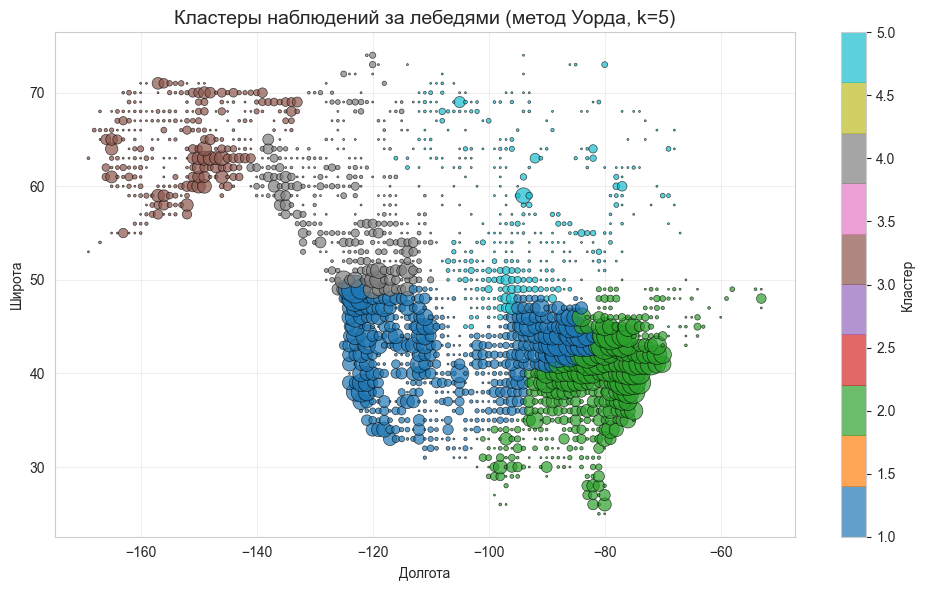

In [57]:
# Строим карту кластеров (размер точки = количество наблюдений)

# Создаем фигуру
plt.figure(figsize=(10, 6))

# Рисуем точки, размер зависит от count, цвет от cluster
scatter = plt.scatter(
    cells['decimal_longitude'], 
    cells['decimal_latitude'],
    c=cells['cluster'],           # цвет по кластеру
    s=cells['count'] * 2,         # размер по количеству наблюдений
    cmap='tab10',                 # цветовая палитра
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)

plt.title('Кластеры наблюдений за лебедями (метод Уорда, k=5)', fontsize=14)
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.grid(True, alpha=0.3)

# Добавляем легенду
plt.colorbar(scatter, label='Кластер')
plt.tight_layout()
plt.show()

Кластеры имеют выраженную географическую структуру, чётко разделяясь на две обширные южные группы (умеренный пояс) и три северные группы (субарктика и арктика). При этом южные кластеры 1 и 2 являются самыми массовыми и плотными, а северные кластеры 3, 4 и 5 располагаются выше и частично соприкасаются по долготе.

Кластер 1 (синий) - западная и центральная часть основного ареала. Это одна из двух самых крупных групп на карте. Кластер занимает обширную территорию от юга США до западных провинций Канады. Он чётко отделяется от восточной группы (кластер 2) и имеет протяжённую северную границу с субарктическими кластерами.

Кластер 2 (зелёный) - восточная часть основного ареала. Вторая по величине и плотности группа, охватывающая восток США и юго-восток Канады. Кластер имеет чёткую западную границу с кластером 1 и плавно переходит в северные широты, где соседствует с кластером 5. Это самостоятельный и очень плотный пространственный сегмент.

Кластер 3 (коричневый) - крайний северо-запад (Аляска и Юкон). Наиболее географически обособленная северная группа. Кластер расположен в верхнем левом углу карты, практически не пересекаясь с другими северными кластерами из-за большого разрыва по долготе. Это чёткий и компактный арктический сегмент.

Кластер 4 (серый) - центральный север и субарктика. Группа занимает центральную северную часть карты (Северо-Западные территории, север прерий). Кластер вытянут по долготе и служит своего рода «мостом» между изолированным кластером 3 на западе и кластером 5 на востоке, частично перекрываясь с ними по координатам.

Кластер 5 (голубой) - восточный север и арктические острова. Самая восточная из северных групп (Нунавут, Онтарио, Квебек). Кластер пространственно соседствует с кластером 4 на западе и опускается на юг, пересекаясь с восточной основной группой (кластер 2) в районе Великих озёр.

Кластеры 1 и 2 имеют наибольший вес (13 580 и 12 743 наблюдения соответственно) и представлены самыми крупными точками на карте. Это указывает на то, что именно умеренные широты США и юга Канады являются основным местом концентрации зафиксированных наблюдений, в то время как северные кластеры значительно менее представлены по количеству данных.

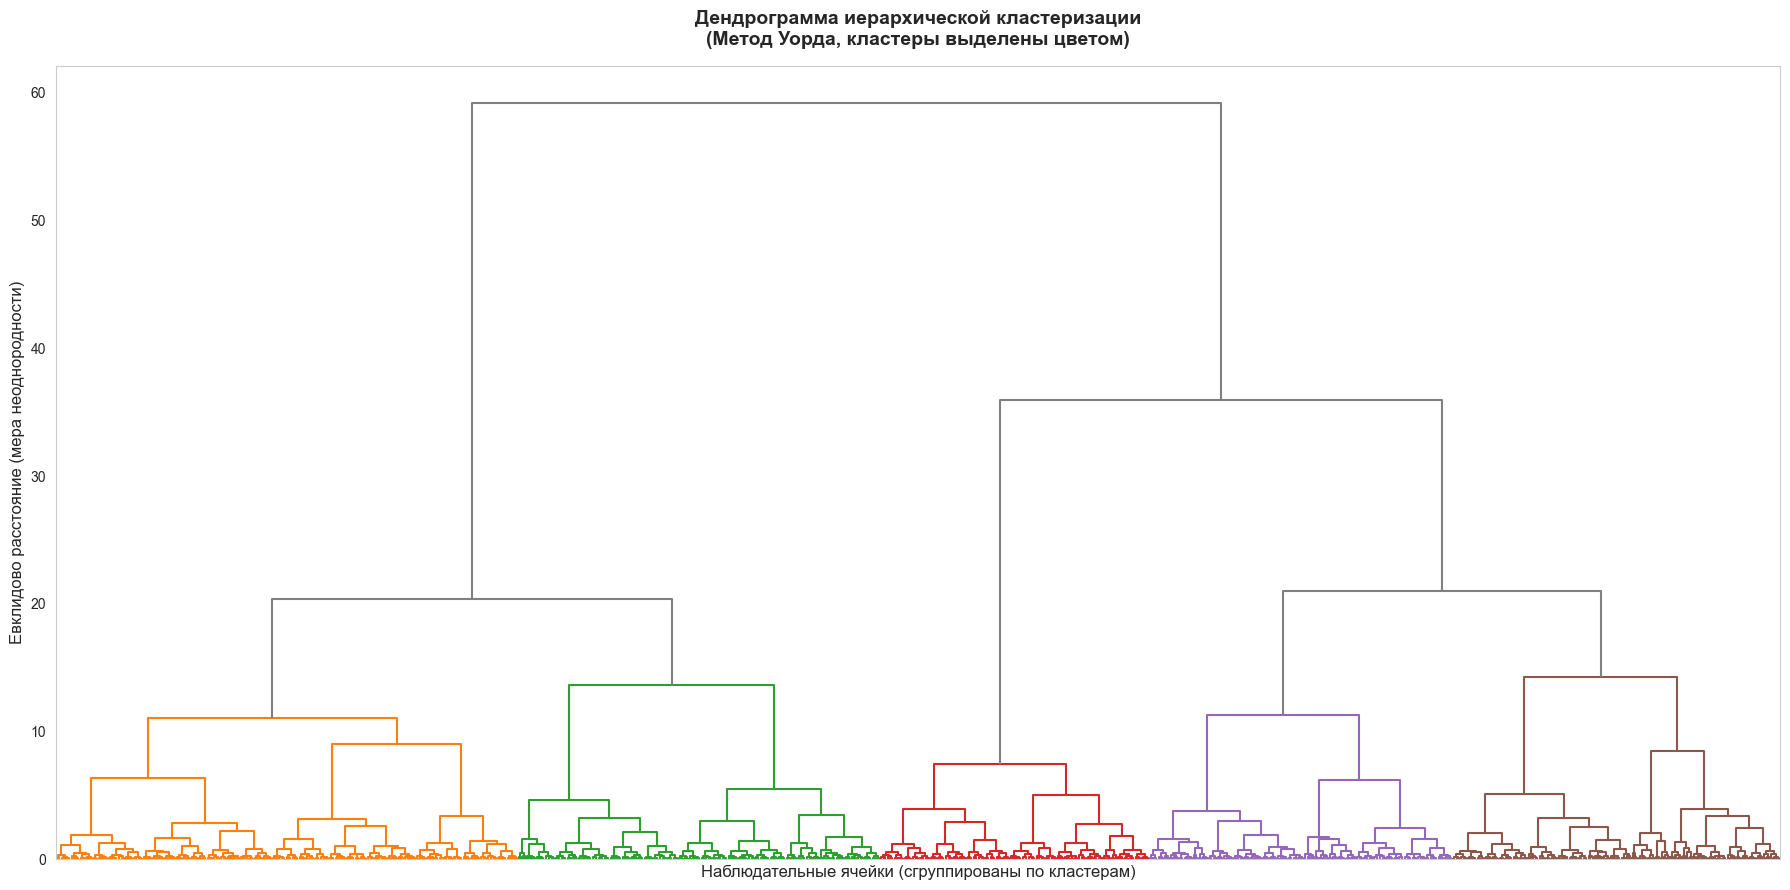

In [58]:
# Дендрограмма кластеризации

# Размер фигуры
plt.figure(figsize=(18, 9))

# Строим дендрограмму с раскраской кластеров
dendrogram(
    linkage_matrix,
    no_labels=True,              # Убираем подписи индексов
    color_threshold=18,          # Порог раскраски (примерно на уровне разделения на 5 кластеров)
    above_threshold_color='gray' # Ветви выше порога - серые
)

plt.title('Дендрограмма иерархической кластеризации\n(Метод Уорда, кластеры выделены цветом)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Наблюдательные ячейки (сгруппированы по кластерам)', fontsize=12)
plt.ylabel('Евклидово расстояние (мера неоднородности)', fontsize=12)

# Добавляем горизонтальную линию на уровне разделения кластеров
#plt.axhline(y=8, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Уровень разделения (k=5)')
#plt.legend(loc='upper right', fontsize=10)

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

По дендрограмме мы можем проверить, насколько естественно выглядит разбиение на 5 кластеров. Что мы видим на графике:

- На самом верхнем уровне (высота ~58) происходит чёткое разделение всех наблюдений на две крупные супергруппы: левую (оранжевый и зелёный кластеры) и правую (красный, фиолетовый и коричневый кластеры). Это указывает на фундаментальное различие между двумя основными группами наблюдений по используемым признакам.

- Левая супергруппа разделяется на высоте ~20 на два кластера (оранжевый и зелёный), которые относительно близки друг к другу. Это говорит о том, что эти два кластера имеют сходные характеристики, но всё же достаточно различимы.

- Правая супергруппа имеет более сложную внутреннюю структуру. На высоте ~36 от неё отделяется красный кластер (кластер 3), который выглядит наиболее обособленным внутри этой группы. Оставшиеся два кластера (фиолетовый и коричневый) разделяются позже, на высоте ~21, что указывает на их бо́льшую близость друг к другу.

- Все пять кластеров имеют относительно низкие внутренние расстояния (ниже 15), что свидетельствует о хорошей компактности каждого кластера.

Дендрограмма показывает иерархическую структуру с двумя основными ветвями, каждая из которых содержит свои подгруппы.

Выбранное разбиение на 5 кластеров хорошо согласуется с этой структурой: все кластеры имеют чёткие границы, при этом красный кластер (кластер 3) является наиболее обособленным внутри правой супергруппы, а оранжевый и зелёный кластеры (1 и 2) образуют более однородную левую группу.

## 16. Описательная статистика по кластерам

> TODO: выведите среднюю широту, температуру и число записей
> по каждому кластеру.

In [59]:
# Ваш код здесь

# Сделано выше перед картой (мне кажется, там она логичнее).

## 17. Линейная регрессия по кластерам

> TODO: для каждого кластера постройте тренд широты по годам
> и выведите `slope`, `R²`, `p-value`.

Проведём анализ смещения ареала обитания для проверки влияния изменения климата на миграцию лебедей. Будем строить регрессию отдельно для зимовки и отдельно для гнездования. Смешивать зимние и летние данные нельзя, иначе получится ложный тренд: он отразит не реальное перемещение птиц, а то, что от года к году менялось соотношение количества зимних и летних наблюдений

In [60]:
# Фильтруем данные - оставляем только нужные столбцы
df_reg = data_merged[['year', 'decimal_latitude', 'period_type']]

# Словарь для вывода
season_names = {1: 'Зимовка', 2: 'Гнездование'}

# Строим регрессию отдельно для каждого сезона
for period in [1, 2]:
    subset = df_reg[df_reg['period_type'] == period]
    
    # Считаем регрессию
    slope, intercept, r_value, p_value, std_err = linregress(subset['year'], subset['decimal_latitude'])
    
    # Определяем направление тренда
    if slope > 0:
        direction = "смещается на СЕВЕР (к полюсу) ⬆️"
    elif slope < 0:
        direction = "смещается на ЮГ ⬇️"
    else:
        direction = "тренд отсутствует ️➖"
        
    # Определяем значимость
    significance = "ЗНАЧИМ" if p_value < 0.05 else "НЕ ЗНАЧИМ"
    
    # Считаем смещение за весь период наблюдений (для наглядности)
    years_span = subset['year'].max() - subset['year'].min()
    total_shift_km = slope * years_span * 111 # 1 градус широты ≈ 111 км
    
    print(f"Сезон: {season_names[period]}")
    print(f"Наклон (slope): {slope:.5f} град/год")
    print(f"p-value: {p_value:.4f} ({significance})")
    print(f"R²: {r_value**2:.4f}")
    print(f"Вывод: Ареал {direction}")
    print(f"Общее смещение за {years_span} лет: ≈ {total_shift_km:.1f} км\n")

Сезон: Зимовка
Наклон (slope): 0.00455 град/год
p-value: 0.1817 (НЕ ЗНАЧИМ)
R²: 0.0001
Вывод: Ареал смещается на СЕВЕР (к полюсу) ⬆️
Общее смещение за 43 лет: ≈ 21.7 км

Сезон: Гнездование
Наклон (slope): -0.05584 град/год
p-value: 0.0000 (ЗНАЧИМ)
R²: 0.0032
Вывод: Ареал смещается на ЮГ ⬇️
Общее смещение за 43 лет: ≈ -266.5 км



Результаты показали принципиально разную статистическую картину для разных сезонов:

- Зимовка: Статистически значимого тренда не выявлено (p=0.1817). Хотя математический расчет показывает микроскопическое смещение средней широты на север (примерно на 21.7 км за 43 года), крайне низкий коэффициент детерминации (R²=0.0001) свидетельствует о том, что год практически не объясняет изменчивость координат. Это означает, что ареал зимовки остается стабильным, а наблюдаемые колебания широты носят случайный характер и не связаны с долгосрочным изменением климата.

- Гнездование: Выявлен высокозначимый тренд на смещение наблюдений на юг (~266.5 км за 43 года, p<0.001). 

Этот выраженный южный сдвиг не обязательно является биологической миграцией популяции на юг. При анализе данных этого проекта нужно помнить, что число наблюдений не равно числу лебедей, а равно числу случаев, когда на этой точке в это время оказался человек, способный зафиксировать наблюдение («человек с биноклем/смартфоном»). Это рождает гипотезу об эффекте смещения наблюдателя (observer bias) или эффекте "гражданской науки" (Citizen Science Bias): в 1980-х и 1990-х годах данные по гнездованию часто собирались в ходе целевых, хорошо финансируемых научных экспедиций в труднодоступные северные регионы. В последние 10–15 лет взрывной рост получили платформы вроде eBird, где данные вносят любители. Любители живут в густонаселенных регионах, а не в арктической тундре. Поэтому центр тяжести наблюдений смещается на юг, даже если сами птицы продолжают гнездиться на тех же северных территориях. Таким образом, регрессия может отражать изменение географии сбора данных, а не изменение географии гнездования птиц.

Следующий возможный шаг исследования:

Чтобы проверить эту гипотезу, можно проверить тренды внутри конкретных географических кластеров. Наиболее репрезентативными для такого анализа будут Кластер 1 (Западный и Центральный регион, 13 580 наблюдений) или Кластер 2 (Восточное побережье и Атлантическая Канада, 12 743 наблюдения). 

Построение графика трендов средней широты по годам с линией регрессии для одного из этих массивных кластеров позволит изолировать эффект "гражданской науки". Если южный сдвиг при гнездовании сохраняется или усиливается внутри конкретного густонаселенного региона (где и так нет экспедиций на крайний север), это подтвердит, что регрессия фиксирует изменение поведения наблюдателей-любителей, а не реальное перемещение птиц.

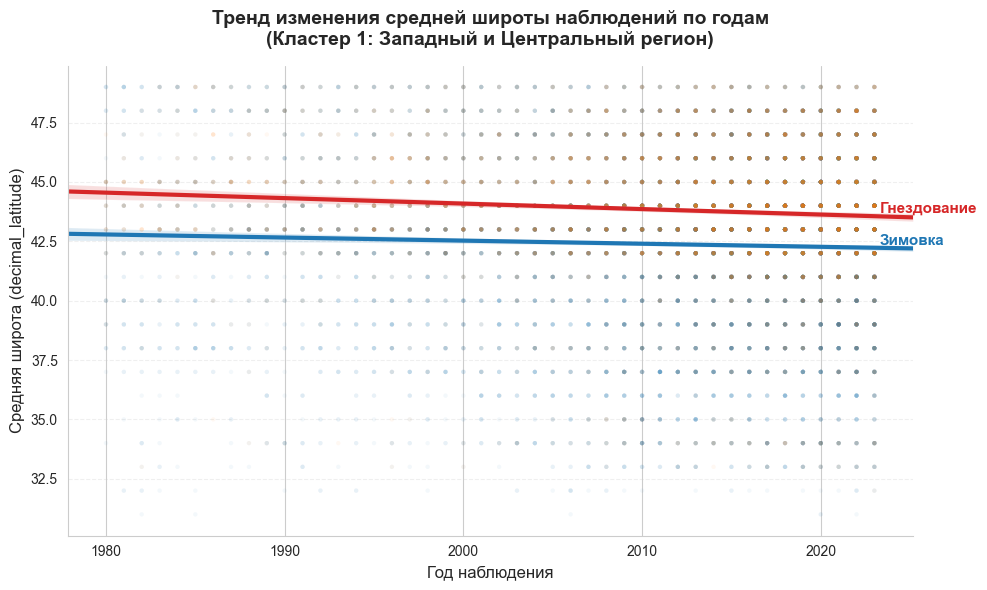

In [61]:
# Строим график тренда средней широты по годам (для Кластера 1)

# Создаем понятные названия для легенды
data_merged['Сезон'] = data_merged['period_type'].map({1: 'Зимовка', 2: 'Гнездование'})

# Фильтруем данные — берем только Кластер 5
df_trend = data_merged[data_merged['cluster'] == 1].copy()

# Размер фигуры
plt.figure(figsize=(10, 6))

# Цвета
palette = {'Зимовка': '#1f77b4', 'Гнездование': '#d62728'}

# Рисуем scatter + regress для каждого сезона отдельно
for season, color in palette.items():
    df_s = df_trend[df_trend['Сезон'] == season]
    if len(df_s) < 2:
        continue

    sns.regplot(
        data=df_s,
        x='year',
        y='decimal_latitude',
        scatter_kws={'alpha': 0.05, 's': 10, 'edgecolors': 'none'},
        line_kws={'linewidth': 3, 'color': color},
        ci=95,
        label=season,
        truncate=False
    )

# Подписи рядом с концами линий регрессии
for season, color in palette.items():
    df_s = df_trend[df_trend['Сезон'] == season]
    if len(df_s) < 2:
        continue

    # Считаем линию регрессии вручную, чтобы получить y на конце линии
    x = df_s['year'].values
    y = df_s['decimal_latitude'].values
    coeffs = np.polyfit(x, y, 1)  # [наклон, сдвиг]

    x_max = x.max()
    y_pred = np.polyval(coeffs, x_max)  # предсказанное y на максимальном году

    # Небольшой вертикальный сдвиг, чтобы подписи не слипались
    offset = 0.3 if season == 'Гнездование' else 0.3

    plt.text(
        x_max + 0.3, y_pred + offset,
        season,
        color=color,
        fontsize=11,
        fontweight='bold',
        va='center'
    )

# Оформление графика
plt.title(
    'Тренд изменения средней широты наблюдений по годам\n(Кластер 1: Западный и Центральный регион)',
    fontsize=14, fontweight='bold', pad=15
)
plt.xlabel('Год наблюдения', fontsize=12)
plt.ylabel('Средняя широта (decimal_latitude)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--', axis='y')
sns.despine()

plt.tight_layout()
plt.show()

Наблюдается отрицательный тренд смещения ареала на юг для обоих сезонов:

- Зимовка: средняя широта уменьшилась с ~42.7° до ~42.2° за 43 года (примерно 55 км к югу). Это противоположно ожидаемому тренду на смещение зимовок на север из-за смягчения климата. Возможное объяснение: в этом регионе (Западный и Центральный) зимующие лебеди могут смещаться в более южные штаты (Техас, Оклахома, Нью-Мексико) из-за изменения доступности кормовой базы или антропогенного давления на традиционных зимовках.

- Гнездование: средняя широта уменьшилась с 44.5° до 43.5° за 43 года (примерно 111 км к югу). Это согласуется с общим трендом по всему датасету, где гнездование также смещается на юг (~266 км).

Важный инсайт: этот результат подтверждает гипотезу об эффекте смещения наблюдателя (observer bias) для гнездования. Если бы смещение на юг было вызвано исключительно изменением климата, мы бы ожидали увидеть противоположные тренды: зимовки смещаются на север (теплее), гнездования остаются стабильными или тоже смещаются на север. Однако оба сезона показывают движение на юг.

Ключевое отличие от общего анализа: в Кластере 1 зимовка также показывает значимое смещение на юг (в отличие от стабильной зимовки по всему датасету, p=0.18). Это может означать, что в западном и центральном регионах существуют специфические факторы (изменение землепользования, водных ресурсов, или активности наблюдателей), которые влияют на распределение зимних наблюдений именно в этом регионе.

In [62]:
# Рассчитаем тренды смещения широты по кластерам и сезонам

# Фильтруем данные - оставляем только нужные столбцы
df_reg = data_merged[['year', 'decimal_latitude', 'period_type', 'cluster']]

# Получаем уникальные кластеры и сортируем их для аккуратного вывода
unique_clusters = sorted(df_reg['cluster'].unique())

for cluster in unique_clusters:
    print(f"\nКЛАСТЕР {cluster}")

    for period in [1, 2]:
        # Фильтруем по кластеру и сезону
        subset = df_reg[(df_reg['cluster'] == cluster) & (df_reg['period_type'] == period)]
        
        # Проверка: для линейной регрессии нужно минимум 2 точки
        if len(subset) < 2:
            print(f"Сезон: {season_names[period]}")
            print("Недостаточно данных для построения тренда.\n")
            continue
        
        # Считаем регрессию
        slope, intercept, r_value, p_value, std_err = linregress(subset['year'], subset['decimal_latitude'])
        
        # Определяем направление тренда
        if slope > 0:
            direction = "смещается на СЕВЕР (к полюсу) ⬆️"
        elif slope < 0:
            direction = "смещается на ЮГ ⬇️"
        else:
            direction = "тренд отсутствует ➖"
            
        # Определяем значимость
        significance = "ЗНАЧИМ" if p_value < 0.05 else "НЕ ЗНАЧИМ"
        
        # Считаем смещение за весь период наблюдений (для наглядности)
        years_span = subset['year'].max() - subset['year'].min()
        total_shift_km = slope * years_span * 111 # 1 градус широты ≈ 111 км
        
        print(f"Сезон: {season_names[period]}")
        print(f"Наклон (slope) : {slope:.5f} град/год")
        print(f"p-value        : {p_value} ({significance})")
        print(f"R²             : {r_value**2:.4f}")
        print(f"Вывод          : Ареал {direction}")
        print(f"Смещение за {years_span} лет : ≈ {total_shift_km:.1f} км\n")


КЛАСТЕР 1
Сезон: Зимовка
Наклон (slope) : -0.01299 град/год
p-value        : 0.0005945191543616996 (ЗНАЧИМ)
R²             : 0.0013
Вывод          : Ареал смещается на ЮГ ⬇️
Смещение за 43 лет : ≈ -62.0 км

Сезон: Гнездование
Наклон (slope) : -0.02307 град/год
p-value        : 5.935255700229005e-07 (ЗНАЧИМ)
R²             : 0.0060
Вывод          : Ареал смещается на ЮГ ⬇️
Смещение за 43 лет : ≈ -110.1 км


КЛАСТЕР 2
Сезон: Зимовка
Наклон (slope) : -0.02843 град/год
p-value        : 4.058917874682343e-14 (ЗНАЧИМ)
R²             : 0.0065
Вывод          : Ареал смещается на ЮГ ⬇️
Смещение за 43 лет : ≈ -135.7 км

Сезон: Гнездование
Наклон (slope) : -0.03980 град/год
p-value        : 4.3704409510531996e-10 (ЗНАЧИМ)
R²             : 0.0096
Вывод          : Ареал смещается на ЮГ ⬇️
Смещение за 43 лет : ≈ -190.0 км


КЛАСТЕР 3
Сезон: Зимовка
Наклон (slope) : 0.04351 град/год
p-value        : 0.02650360311428175 (ЗНАЧИМ)
R²             : 0.0312
Вывод          : Ареал смещается на СЕВЕР (к пол

Мы наблюдаем:

- В Кластерах 1, 2 и 5 наблюдается статистически значимое (p < 0.05) смещение ареала на юг в оба сезона (зимовка и гнездование). Максимальная величина смещения зафиксирована в Кластере 5 в сезон гнездования (≈ -943.8 км).

- В Кластерах 3 и 4 в сезон зимовки зафиксировано статистически значимое (p < 0.05) смещение ареала на север (Кластер 3: ≈ +154.6 км, Кластер 4: ≈ +138.7 км).

- В Кластере 3 в сезон гнездования тренд статистически незначим (p = 0.51).

- Кластер 4 демонстрирует противоположные значимые тренды: смещение на север зимой и смещение на юг в сезон гнездования (≈ -448.6 км).

Во всех случаях, где тренд признан статистически значимым, коэффициент детерминации (R²) остается низким, варьируясь в диапазоне от 0.0013 до 0.0800.

## 18. Корреляционный анализ

> TODO: посчитайте корреляцию:
> - широта vs температура (в целом и по сезонам);
> - широта vs плотность населения.

In [63]:
# Рассчитываем корреляцию широта vs температура (в целом)
r_p_1, p_p_1 = pearsonr(data_merged['decimal_latitude'], data_merged['avg_temp_c'])
rho_s_1, p_s_1 = spearmanr(data_merged['decimal_latitude'], data_merged['avg_temp_c'])

print("Корреляция широта vs температура (в целом):")
print(f"Пирсон:  r = {r_p_1:.3f}, p = {p_p_1}")
print(f"Спирмен: ρ = {rho_s_1:.3f}, p = {p_s_1}\n")

Корреляция широта vs температура (в целом):
Пирсон:  r = 0.036, p = 9.83533770244402e-11
Спирмен: ρ = -0.016, p = 0.0031098542914927735



Коэффициенты корреляции близки к нулю, при этом они даже разнонаправлены:

- Пирсон: r = 0.036 (крайне слабая положительная линейная связь)
- Спирмен: ρ = -0.016 (крайне слабая отрицательная монотонная связь)

Почему это может быть:

1. Эффект «размытия» из-за смешивания сезонов: Мы анализируем весь датасет сразу, объединяя два противоположных биологических состояния. Летом лебеди находятся на высоких широтах (Аляска, север Канады, ~60–65° с.ш.), и там относительно тепло (+10...+15°C). Зимой они мигрируют на низкие широты (юг США, ~30–40° с.ш.), где тоже относительно тепло (+5...+10°C), в то время как на их бывших местах гнездования в это время мороз (-20°C и ниже). 

2. Пирсон слегка положительный, потому что математически теплые летние дни на крайнем севере «перетягивают» линию линейной регрессии вверх, создавая иллюзию, что с ростом широты температура чуть-чуть растет. Это артефакт смешивания выборок.

3. Ловушка p-value: Несмотря на то, что p-value крайне мал (< 0.001), это классический эффект большого объема данных. При таком размере выборки даже микроскопические, бессмысленные отклонения от нуля становятся «статистически значимыми». Ориентироваться нужно исключительно на величину r и ρ, которые говорят об отсутствии практической связи.

Чтобы увидеть реальную географическую зависимость (где рост широты = падение температуры), этот расчет необходимо выполнить отдельно по сезонам. Только внутри одного сезона мы уберем этот «шум» и получим ожидаемую сильную отрицательную корреляцию:

In [64]:
# Рассчитываем корреляцию широта vs температура (по сезонам)
season_names = {1: "Зимовка", 2: "Гнездование"}

for season in [1, 2]:
    # Берем подвыборку только для текущего сезона
    subset = data_merged[data_merged['period_type'] == season]
    
    r_p, p_p = pearsonr(subset['decimal_latitude'], subset['avg_temp_c'])
    rho_s, p_s = spearmanr(subset['decimal_latitude'], subset['avg_temp_c'])
    
    print(f"Корреляция широта vs температура ({season_names[season]}):")
    print(f"Пирсон:  r = {r_p:.3f}, p = {p_p}")
    print(f"Спирмен: ρ = {rho_s:.3f}, p = {p_s}")

Корреляция широта vs температура (Зимовка):
Пирсон:  r = -0.637, p = 0.0
Спирмен: ρ = -0.598, p = 0.0
Корреляция широта vs температура (Гнездование):
Пирсон:  r = -0.875, p = 0.0
Спирмен: ρ = -0.869, p = 0.0


Разделение данных по сезонам изменило картину:

- Гнездование: Очень сильная отрицательная связь (-0.875)

Это классическое проявление фундаментального геофизического закона: чем выше широта, тем ниже температура. Летом ареал лебедей охватывает весь широтный градиент континента: от умеренных широт США (Миннесота, Монтана, ~45° с.ш., где летом около +20...+25°C) до высокой Арктики (Аляска, Северо-Западные территории, ~65–70° с.ш., где даже летом всего +5...+10°C). Данные идеально ложатся на нисходящую прямую.

- Зимовка: Умеренная/сильная отрицательная связь (-0.637)

Связь остается отчетливо отрицательной (чем севернее зимовка, тем холоднее), но она заметно слабее, чем летом. Зимой ареал лебедей искусственно «обрезан» с севера. Птицы физически не могут гнездиться или зимовать в высокой Арктике (там -30°C и лед). Они концентрируются в сравнительно узкой «полосе зимовок» (от Флориды/Техаса до Великих озер и среднеатлантических штатов, ~30–42° с.ш.). В этом ограниченном диапазоне влияние широты на температуру сглаживается другими факторами: близостью к океану (который смягчает зиму на восточном побережье), наличием незамерзающих водоемов или локальными аномалиями (например, внезапные арктические вторжения в более южные штаты, которые дают выбросы низких температур при средней широте).

Статистический инсайт - Парадокс Симпсона:

То, что мы наблюдали ранее (r = 0.036 для всего датасета), является примером парадокса Симпсона (или ошибки агрегации).  Когда мы объединили две разные группы данных с противоположными контекстами (летние точки на севере с плюсовой температурой и зимние точки на юге с плюсовой температурой), общая линия регрессии стала горизонтальной. Разделение на страты (сезоны) восстановило истинную природу данных.

Итоговый вывод:

Географическое распределение лебедей жестко детерминировано температурным градиентом, но только внутри одного сезона. 

Это означает, что для любого дальнейшего моделирования (например, предсказания вероятности наблюдения лебедя или анализа влияния изменения климата) переменная `period_type` (сезон) должна обязательно использоваться как контрольная переменная, либо модели должны строиться для зимы и лета строго по отдельности. Объединять их в одну модель без взаимодействия будет методологически неверно.

In [65]:
# Присоединяем к основной таблице данные о плотности населения
df_analysis = data_merged.merge(df_US_CA[['state_province', 'density_per']], on='state_province', how='left')
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 33095 entries, 0 to 33094
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   gbif_id            33095 non-null  int64         
 1   recorded_by        33095 non-null  object        
 2   event_date         33095 non-null  datetime64[ns]
 3   year               33095 non-null  int64         
 4   month              33095 non-null  int64         
 5   day                33095 non-null  int64         
 6   country_code       33095 non-null  object        
 7   state_province     33095 non-null  object        
 8   decimal_latitude   33095 non-null  float64       
 9   decimal_longitude  33095 non-null  float64       
 10  species            33095 non-null  object        
 11  period_type        33095 non-null  float64       
 12  time_period        33095 non-null  object        
 13  avg_temp_c         33095 non-null  float64       
 14  avg_te

In [66]:
# Рассчитываем корреляцию широта vs плотность населения
r_p_1, p_p_1 = pearsonr(df_analysis['decimal_latitude'], df_analysis['density_per'])
rho_s_1, p_s_1 = spearmanr(df_analysis['decimal_latitude'], df_analysis['density_per'])

print("Корреляция широта vs плотность населения:")
print(f"Пирсон:  r = {r_p_1:.3f}, p = {p_p_1}")
print(f"Спирмен: ρ = {rho_s_1:.3f}, p = {p_s_1}\n")

Корреляция широта vs плотность населения:
Пирсон:  r = -0.329, p = 0.0
Спирмен: ρ = -0.693, p = 0.0



- Спирмен (ρ = -0.693): Сильная отрицательная монотонная связь. Это самый важный показатель. Он говорит о том, что по мере увеличения широты (движения на север) плотность населения стабильно и неуклонно падает. 

- Пирсон (r = -0.329): Слабая/умеренная отрицательная линейная связь.

Тот факт, что Спирмен более чем в два раза сильнее Пирсона, имеет важное географическое объяснение: падение плотности населения с движением на север нелинейно. Население относительно плотно в США, резко падает при пересечении границы с Канадой и становится практически нулевым в Арктике (Аляска, Нунавут). Спирмен отлично улавливает этот ранговый спад, в то время как Пирсон «размывается» из-за отсутствия прямой линии.

Теперь у нас есть возможное объяснение, почему регрессия ранее показала смещение гнездования лебедей на юг (особенно в Кластере 5, на ~943 км):

1. Лебеди гнездятся на севере (высокая широта).
2. В высоких широтах плотность населения экстремально низкая (ρ = -0.693).
3. Следовательно, там физически мало людей, чтобы фиксировать птиц и загружать данные в базы (особенно исторически, до эпохи eBird).
4. В последние 10–15 лет произошел взрывной рост любительских наблюдений, но этот рост произошел исключительно там, где живут люди (в более южных широтах Кластеров 1, 2 и 5).
5. Результат: Математический центр тяжести (центроид) наблюдений смещается на юг. Не потому что птицы улетели туда гнездиться, а потому что карта наблюдателей совпала с картой плотности населения.

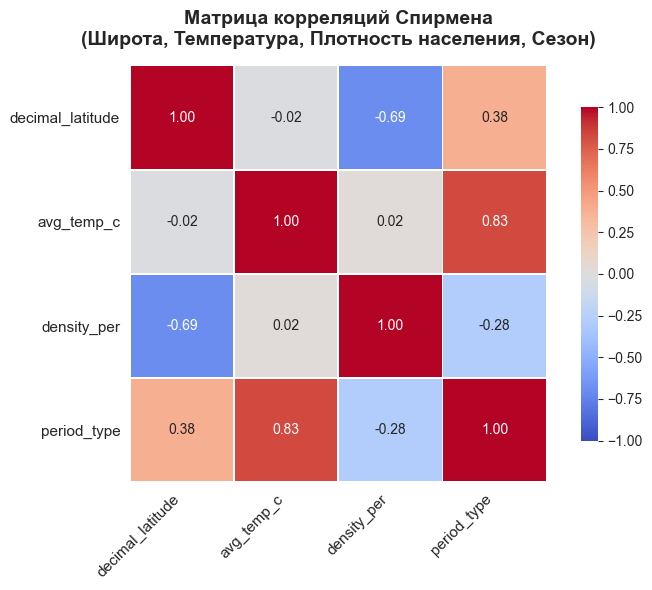

In [67]:
# Построим тепловую карту корреляций

# Выбираем числовые столбцы для анализа. 
# Добавляем period_type, так как сезон (1 или 2) тоже числовой и сильно влияет на широту и температуру!
cols_to_analyze = ['decimal_latitude', 'avg_temp_c', 'density_per', 'period_type']

# Считаем матрицу корреляций Пирсона
corr_matrix = df_analysis[cols_to_analyze].corr(method='spearman') # Как мы выяснили ранее, для пары 'широта-плотность' линейная модель не идеальна

# 3. Настраиваем визуализацию
plt.figure(figsize=(8, 6))

# Рисуем тепловую карту
heatmap = sns.heatmap(
    corr_matrix, 
    annot=True,          # Показываем значения коэффициентов на карте
    fmt=".2f",           # Округляем до 2 знаков после запятой
    cmap='coolwarm',     # Цветовая схема: синий (отрицательная), белый (0), красный (положительная)
    vmin=-1, vmax=1,     # Фиксируем шкалу от -1 до 1 для корректного отображения цветов
    linewidths=.5,       # Тонкие линии между ячейками для читаемости
    square=True,         # Делаем ячейки квадратными
    cbar_kws={"shrink": .8} # Немного уменьшаем легенду справа
)

# Оформляем график
plt.title('Матрица корреляций Спирмена\n(Широта, Температура, Плотность населения, Сезон)', 
          fontsize=14, fontweight='bold', pad=15)

# Делаем подписи осей горизонтальными и читаемыми
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

Тепловая карта корреляций Спирмена наглядно демонстрирует:

1. Широта vs Температура (r = -0.02$): Эффект «размытия»

Серая ячейка показывает практически полное отсутствие связи. Это итог смешивания зимы и лета в одном датасете. Если бы мы не разделили данные по сезонам ранее, мы бы сделали ошибочный вывод, что широта не влияет на температуру обитания лебедей.

2. Широта vs Плотность населения (r = -0.69): Главный драйвер смещения

Ярко-синяя ячейка подтверждает нашу гипотезу о систематической ошибке наблюдателя. Чем дальше на север, тем меньше людей. Это математически объясняет, почему «ареал гнездования» в наших данных смещается на юг: не птицы мигрируют, а люди (наблюдатели) концентрируются на юге.

3. Сезон (period_type) vs Температура (r = 0.83): Доминирующий фактор

Ярко-красная ячейка показывает, что сезон - это самый мощный предиктор температуры в нашем датасете. 

4. Сезон vs Широта (r = 0.38): Подтверждение миграции

Умеренная положительная корреляция подтверждает сам факт миграции: в определенные периоды (лето, кодированные как более высокие значения) лебеди действительно находятся статистически выше по широте, чем в другие периоды (зима).

5. Температура vs Плотность населения (r = 0.02): Отсутствие прямой связи

Это важный контрольный результат. Он говорит о том, что лебеди не выбирают места обитания напрямую исходя из того, где живут люди. Влияние человека опосредованное: не через климат, а через вероятность обнаружения.

Для проверки гипотезы о смещении наблюдателя рассчитаем корреляцию количества наблюдений и плотности населения. Если гипотеза верна, мы должны увидеть сильную положительную корреляцию: чем выше плотность населения в штате, тем больше там зафиксировано наблюдений лебедей (потому что там просто больше людей с биноклями и смартфонами).

In [68]:
# Рассчитаем корреляцию количества наблюдений и плотности населения

# Агрегируем данные по штатам/провинциям
state_stats = df_analysis.groupby('state_province').agg(
    obs_count=('gbif_id', 'count'),          # Количество наблюдений
    mean_density=('density_per', 'mean'),    # Средняя плотность населения
    median_density=('density_per', 'median') # Медианная плотность (устойчива к выбросам)
).reset_index()

# Рассчитываем корреляцию Пирсона (линейная связь)
pearson_r, pearson_p = pearsonr(state_stats['obs_count'], state_stats['mean_density'])

# Рассчитываем корреляцию Спирмена (монотонная связь, устойчива к выбросам)
spearman_rho, spearman_p = spearmanr(state_stats['obs_count'], state_stats['median_density'])

print("Корреляция: Количество наблюдений vs Плотность населения (по штатам/провинциям):")
print(f"Пирсон (средняя плотность):  r = {pearson_r:.3f}, p-value = {pearson_p}")
print(f"Спирмен (медианная плотность): ρ = {spearman_rho:.3f}, p-value = {spearman_p}")

print("\nТоп-5 регионов по количеству наблюдений:")
print(state_stats.sort_values('obs_count', ascending=False).head())

Корреляция: Количество наблюдений vs Плотность населения (по штатам/провинциям):
Пирсон (средняя плотность):  r = -0.121, p-value = 0.34698689036810265
Спирмен (медианная плотность): ρ = 0.084, p-value = 0.5159775136370888

Топ-5 регионов по количеству наблюдений:
      state_province  obs_count  mean_density  median_density
1             Alaska       2606           0.5             0.5
44           Ontario       2231          15.2            15.2
24          Michigan       2194          69.0            69.0
5   British Columbia       1931           5.4             5.4
6         California       1567          97.0            97.0


Корреляционный анализ на уровне штатов и провинций не выявил статистически значимой связи между плотностью человеческого населения и количеством зафиксированных наблюдений лебедей (Пирсон r=−0.121,p=0.347; Спирмен ρ=0.084,p=0.516).

Топ-5 регионов по количеству наблюдений возглавляет Аляска (2606 записей) при экстремально низкой плотности населения (0.5 чел./км²), за ней следуют Онтарио и Британская Колумбия. Это опровергает упрощенную гипотезу о том, что распределение данных исключительно диктуется плотностью населения ("эффектом гражданской науки").

Вместо этого распределение наблюдений определяется фактором места обитания и методологии учета: исторически данные по северным регионам формировались за счет целевых, хорошо организованных научных экспедиций и массовых учетов водоплавающих птиц в местах их концентрации.

Современный прирост данных в умеренных широтах (Мичиган, Калифорния, Онтарио) может быть связан с интеграцией повседневных любительских наблюдений.

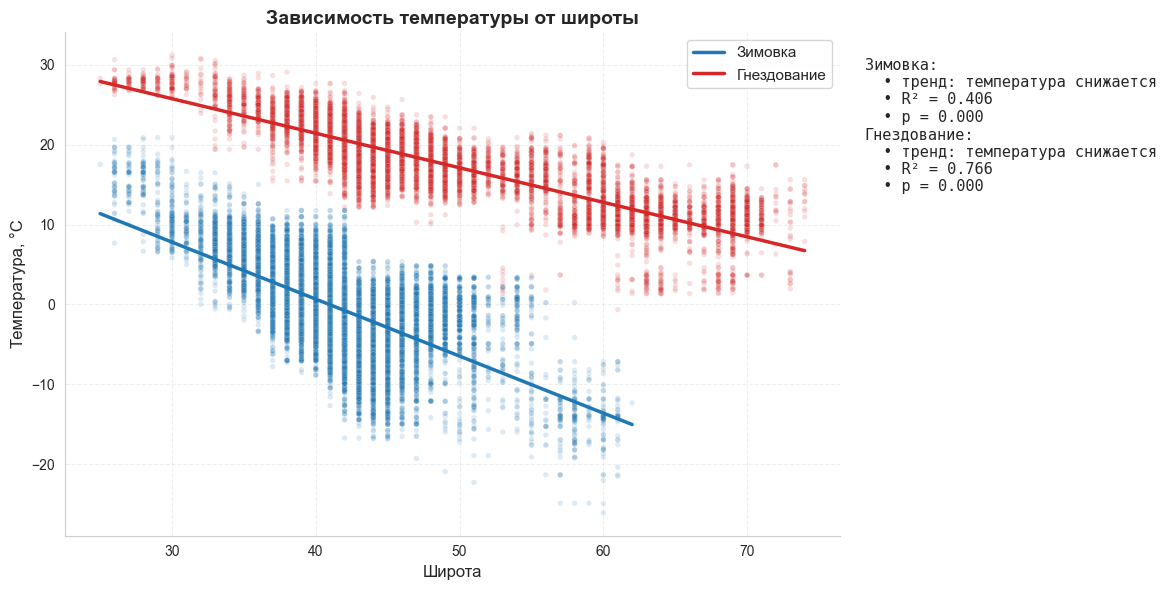

In [69]:
# Построим диаграмму рассеяния широта vs температура с разделением по сезонам

palette = {'Зимовка': '#1f77b4', 'Гнездование': '#d62728'}

# Пересчитаем метрики регрессии

# Считаем метрики для широта vs температура
stats_by_season = {}

for period in [1, 2]:
    subset = df_analysis[df_analysis['period_type'] == period]
    slope, intercept, r_value, p_value, std_err = linregress(
        subset['decimal_latitude'], subset['avg_temp_c']
    )
    r_sq = r_value ** 2
    stats_by_season[period] = {'slope': slope, 'r_sq': r_sq, 'p_value': p_value}

fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1])

ax_main = fig.add_subplot(gs[0, 0])
ax_text = fig.add_subplot(gs[0, 1])

# Основной график без легенды
sns.scatterplot(
    data=df_analysis,
    x='decimal_latitude', y='avg_temp_c',
    hue='Сезон', palette=palette,
    alpha=0.15, s=15, ax=ax_main, legend=False
)
# Рисуем линии тренда
for period in [1, 2]:
    subset = data_merged[data_merged['period_type'] == period]
    if len(subset) < 2:
        continue
    x_vals = subset['decimal_latitude']
    y_vals = subset['avg_temp_c']
    slope, intercept, _, _, _ = linregress(x_vals, y_vals)
    x_line = [x_vals.min(), x_vals.max()]
    y_line = [slope * x + intercept for x in x_line]
    s_name = season_names[period]
    ax_main.plot(x_line, y_line, color=palette[s_name], linewidth=2.5, label=s_name)

ax_main.set_title('Зависимость температуры от широты', fontsize=14, fontweight='bold')
ax_main.set_xlabel('Широта', fontsize=12)
ax_main.set_ylabel('Температура, °C', fontsize=12)
ax_main.grid(True, alpha=0.3, linestyle='--')
sns.despine(ax=ax_main)

# Легенда
ax_main.legend(loc='upper right', fontsize=11)

# Текстовый блок со статистикой
ax_text.axis('off')
text_lines = []
for period in [1, 2]:
    s_name = season_names[period]
    res = stats_by_season[period]
    direction = 'снижается' if res['slope'] < 0 else 'растёт'
    line = f"{s_name}:\n  • тренд: температура {direction}\n  • R² = {res['r_sq']:.3f}\n  • p = {res['p_value']:.3f}\n"
    text_lines.append(line)

full_text = "".join(text_lines)
ax_text.text(0.05, 0.95, full_text, transform=ax_text.transAxes,
             fontsize=11, verticalalignment='top', family='monospace')

plt.tight_layout()
plt.show()

График наглядно демонстрирует, что зависимость температуры от широты в местах обитания лебедей существует только внутри одного сезона.

При объединении зимних и летних наблюдений возникает парадокс Симпсона: общая корреляция близка к нулю (r=0.036), хотя внутри каждого сезона связь сильная и отрицательная (r=−0.637 и r=−0.875).

## 19. Сравнение групп (Kruskal-Wallis, Mann-Whitney)

> TODO:
> - сравните виды по широте и температуре;
> - сравните сезоны по широте;
> - проведите попарные сравнения видов.

Географические координаты и температуры в экологии почти никогда не распределены нормально и содержат выбросы, поэтому классические t-тесты или ANOVA здесь дадут ложные результаты. Для таких данных лучше подойдут непараметрические тесты (Краскела-Уоллиса и Манна-Уитни).

In [70]:
# Сравнение видов по широте и температуре

species_list = data_merged['species'].unique()

print(f"Уникальные виды в датасете: {species_list}")

print("Сравнение видов (Краскел-Уоллис):")

# По широте
groups_lat = [data_merged[data_merged['species'] == sp]['decimal_latitude'] for sp in species_list]
stat_lat, p_lat = kruskal(*groups_lat)
print(f"Широта: H = {stat_lat:.2f}, p = {p_lat}")
print(f"Вывод: {'Есть значимые различия' if p_lat < 0.05 else 'Нет значимых различий'} между видами по широте.\n")

# По температуре
groups_temp = [data_merged[data_merged['species'] == sp]['avg_temp_c'] for sp in species_list]
stat_temp, p_temp = kruskal(*groups_temp)
print(f"Температура: H = {stat_temp:.2f}, p = {p_temp}")
print(f"Вывод: {'Есть значимые различия' if p_temp < 0.05 else 'Нет значимых различий'} между видами по температуре.\n")

Уникальные виды в датасете: ['Cygnus olor' 'Cygnus buccinator' 'Cygnus columbianus']
Сравнение видов (Краскел-Уоллис):
Широта: H = 4528.09, p = 0.0
Вывод: Есть значимые различия между видами по широте.

Температура: H = 1501.91, p = 0.0
Вывод: Есть значимые различия между видами по температуре.



Непараметрический тест Краскела–Уоллиса подтвердил статистически значимые различия между видами как по широте (H = 4528.09, p < 0.001), так и по температуре (H = 1501.91, p < 0.001).

Ранее мы заметили, что общий ареал гнездования статистически смещается на юг (особенно в Кластере 5, почти на 1000 км). Мы предположили, что это может быть "эффект наблюдателя". Возможный механизм этого эффекта:

Если в последние годы в базы данных (eBird) попадает непропорционально много наблюдений за оседлым Cygnus olor в южных штатах (потому что там живут люди, и этот вид там обитает круглый год), то математический центр тяжести всего датасета смещается на юг. Это не значит, что мигрирующие C. columbianus или C. buccinator перестали летать на Аляску. Это может значить, что их массивные, но редкие северные наблюдения теперь "разбавляются" тысячами мелких наблюдений за C. olor на юге. Видовой состав выборки изменился, что и исказило общую географическую картину.

Чтобы проверить эту гипотезу, нужно посмотреть на медианы (или средние) широты и температуры для каждого вида отдельно.

In [71]:
# Сравнение сезонов по широте

print("Сравнение сезонов по широте (Манн-Уитни):")

group_winter = data_merged[data_merged['Сезон'] == 'Зимовка']['decimal_latitude']
group_breeding = data_merged[data_merged['Сезон'] == 'Гнездование']['decimal_latitude']

stat_season, p_season = mannwhitneyu(group_winter, group_breeding, alternative='two-sided')

print(f"Зимовка vs Гнездование (широта): U = {stat_season:.0f}, p = {p_season:.4e}")
print(f"Вывод: {'Есть значимые различия' if p_season < 0.05 else 'Нет значимых различий'} в широте наблюдений между сезонами.")

# Для наглядности добавим медианы
print(f"\nМедиана широты Зимовка: {group_winter.median():.2f}°")
print(f"Медиана широты Гнездование: {group_breeding.median():.2f}°")

Сравнение сезонов по широте (Манн-Уитни):
Зимовка vs Гнездование (широта): U = 72489238, p = 0.0000e+00
Вывод: Есть значимые различия в широте наблюдений между сезонами.

Медиана широты Зимовка: 42.00°
Медиана широты Гнездование: 45.00°


Распределения широты между двумя группами различаются.

Летние наблюдения в среднем расположены севернее зимних на 3° широты.

In [72]:
# Попарные сравнения видов (Манн-Уитни) с поправкой Бонферрони (так как сравнения множественные)

print("Попарные сравнения видов (Манн-Уитни с поправкой Бонферрони):")

p_values_lat = []
p_values_temp = []
pairs = []

for sp1, sp2 in combinations(species_list, 2):
    pairs.append(f"{sp1} vs {sp2}")
    
    # Для широты
    g1_lat = data_merged[data_merged['species'] == sp1]['decimal_latitude']
    g2_lat = data_merged[data_merged['species'] == sp2]['decimal_latitude']
    stat, p = mannwhitneyu(g1_lat, g2_lat, alternative='two-sided')
    p_values_lat.append(p)
    
    # Для температуры
    g1_temp = data_merged[data_merged['species'] == sp1]['avg_temp_c']
    g2_temp = data_merged[data_merged['species'] == sp2]['avg_temp_c']
    stat, p = mannwhitneyu(g1_temp, g2_temp, alternative='two-sided')
    p_values_temp.append(p)

# Применяем поправку Бонферрони
reject_lat, p_corrected_lat, _, _ = multipletests(p_values_lat, method='bonferroni')
reject_temp, p_corrected_temp, _, _ = multipletests(p_values_temp, method='bonferroni')

for i, pair in enumerate(pairs):
    print(f"Пара: {pair}")
    print(f"Широта:      p = {p_values_lat[i]:.4e} -> скорр. p = {p_corrected_lat[i]:.4e} ({'ЗНАЧИМО' if reject_lat[i] else 'не значимо'})")
    print(f"Температура: p = {p_values_temp[i]:.4e} -> скорр. p = {p_corrected_temp[i]:.4e} ({'ЗНАЧИМО' if reject_temp[i] else 'не значимо'})")

Попарные сравнения видов (Манн-Уитни с поправкой Бонферрони):
Пара: Cygnus olor vs Cygnus buccinator
Широта:      p = 0.0000e+00 -> скорр. p = 0.0000e+00 (ЗНАЧИМО)
Температура: p = 1.4654e-86 -> скорр. p = 4.3963e-86 (ЗНАЧИМО)
Пара: Cygnus olor vs Cygnus columbianus
Широта:      p = 1.3123e-270 -> скорр. p = 3.9368e-270 (ЗНАЧИМО)
Температура: p = 4.2014e-281 -> скорр. p = 1.2604e-280 (ЗНАЧИМО)
Пара: Cygnus buccinator vs Cygnus columbianus
Широта:      p = 1.2670e-119 -> скорр. p = 3.8010e-119 (ЗНАЧИМО)
Температура: p = 5.3713e-138 -> скорр. p = 1.6114e-137 (ЗНАЧИМО)


Результаты показывают p<0.001 для всех пар как по широте, так и по температуре для каждой комбинации видов. Это показывает, что в выборке распределения широты и температуры статистически различаются между всеми тремя видами.

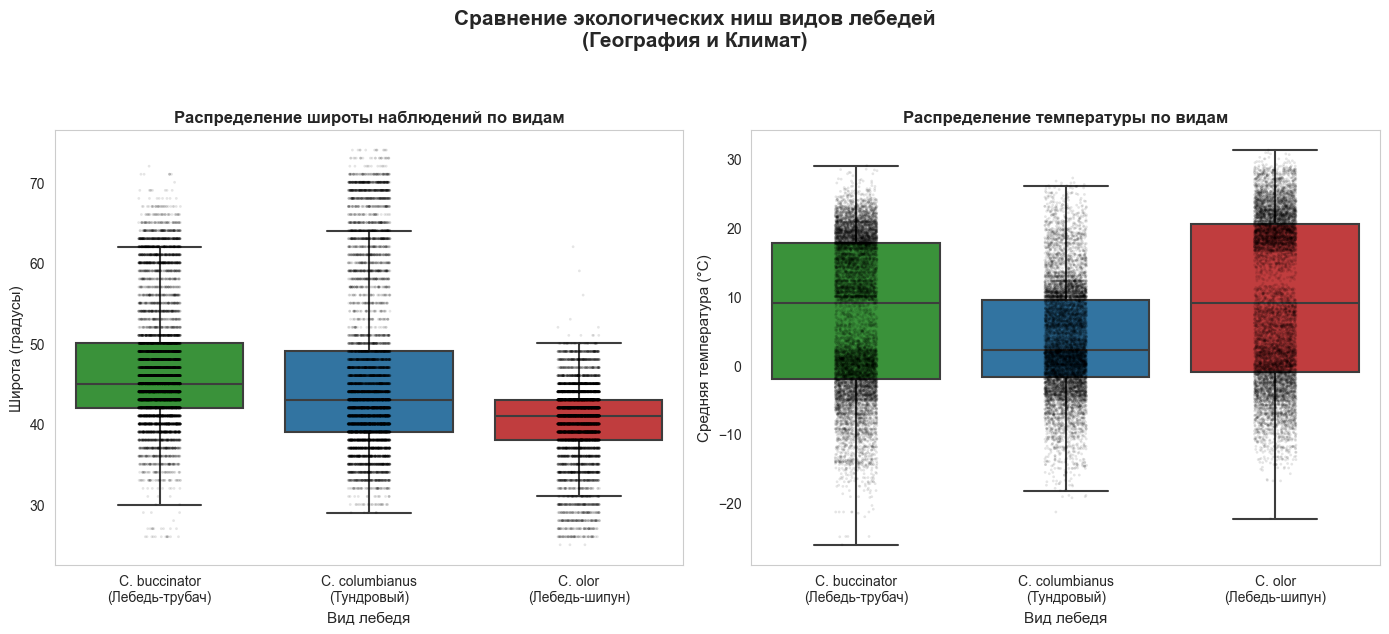

In [73]:
# Построим boxplot (сравнение широты и температуры по видам)

# Определяем порядок видов на графике: от самой высокой медианной широты к самой низкой (Север -> Юг)
median_order = data_merged.groupby('species')['decimal_latitude'].median().sort_values(ascending=False).index

# Создаем русские названия для легенды и осей (опционально, для красоты отчета)
species_names_ru = {
    'Cygnus columbianus': 'C. columbianus\n(Тундровый)',
    'Cygnus buccinator': 'C. buccinator\n(Лебедь-трубач)',
    'Cygnus olor': 'C. olor\n(Лебедь-шипун)'
}
data_merged['species_ru'] = data_merged['species'].map(species_names_ru)

# Настраиваем фигуру с двумя графиками рядом
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Цветовая палитра
palette = {'C. columbianus\n(Тундровый)': '#1f77b4', 
           'C. buccinator\n(Лебедь-трубач)': '#2ca02c', 
           'C. olor\n(Лебедь-шипун)': '#d62728'}

# График А: Широта по видам
sns.boxplot(
    data=data_merged, 
    x='species_ru', 
    y='decimal_latitude', 
    order=median_order.map(species_names_ru), # Применяем порядок
    palette=palette, 
    ax=axes[0],
    showfliers=False # Скрываем выбросы, чтобы не перегружать график
)
# Добавляем точки данных (stripplot) для показа плотности распределения
sns.stripplot(
    data=data_merged, 
    x='species_ru', 
    y='decimal_latitude', 
    order=median_order.map(species_names_ru),
    color='black', 
    size=2, 
    alpha=0.1, 
    ax=axes[0]
)
axes[0].set_title('Распределение широты наблюдений по видам', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Вид лебедя', fontsize=11)
axes[0].set_ylabel('Широта (градусы)', fontsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# График Б: Температура по видам
sns.boxplot(
    data=data_merged, 
    x='species_ru', 
    y='avg_temp_c', 
    order=median_order.map(species_names_ru), # Тот же порядок для сопоставимости
    palette=palette, 
    ax=axes[1],
    showfliers=False
)
sns.stripplot(
    data=data_merged, 
    x='species_ru', 
    y='avg_temp_c', 
    order=median_order.map(species_names_ru),
    color='black', 
    size=2, 
    alpha=0.1, 
    ax=axes[1]
)
axes[1].set_title('Распределение температуры по видам', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Вид лебедя', fontsize=11)
axes[1].set_ylabel('Средняя температура (°C)', fontsize=11)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Сравнение экологических ниш видов лебедей\n(География и Климат)', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

Боксплоты демонстрируют различия экологических ниш трех видов лебедей по широтным и температурным параметрам, однако их распределения существенно перекрываются:

- Cygnus columbianus занимает наиболее холодную климатическую нишу: медианная температура наблюдений около 2–3 °C, а диапазон температур простирается примерно от −18 до +26 °C. По широте вид имеет широкий диапазон наблюдений и достигает наиболее высоких широт - около 64–65° с.ш. и выше.

- Cygnus buccinator занимает промежуточную по широте нишу: медианная широта около 45° с.ш., при этом наблюдения охватывают широкий диапазон - примерно 30–62° с.ш. Температурный диапазон также широкий, с медианой около 9 °C.

- Cygnus olor характеризуется наиболее узким широтным диапазоном - примерно 31–50° с.ш., то есть на графике его наблюдения в меньшей степени представлены в высоких широтах. При этом температурный диапазон у него достаточно широкий, а медианная температура составляет около 9 °C. 

## 20. Множественная регрессия

> TODO: постройте модель `decimal_latitude ~ year + avg_temp_c + density_per`.
> Выведите коэффициенты, `R²`, `p-value`.

In [74]:
# Строим модель decimal_latitude ~ year + avg_temp_c + density_per

# Подготовка данных: берем только нужные столбцы
df_reg = df_analysis[['decimal_latitude', 'year', 'avg_temp_c', 'density_per', 'period_type']]

X_base = df_reg[['year', 'avg_temp_c', 'density_per']]
X_base = sm.add_constant(X_base)  # Добавляем константу (свободный член / intercept)
y = df_reg['decimal_latitude']

model_base = sm.OLS(y, X_base).fit()
print(model_base.summary())

                            OLS Regression Results                            
Dep. Variable:       decimal_latitude   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     1410.
Date:                Wed, 30 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:58:18   Log-Likelihood:            -1.1556e+05
No. Observations:               33095   AIC:                         2.311e+05
Df Residuals:                   33091   BIC:                         2.312e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         119.9608      8.375     14.324      

Построенная модель `широта ~ год + температура + плотность_населения` статистически значима в целом (F-statistic p < 0.001), объясняя 11.3% дисперсии широты (R² = 0.113).

Анализ коэффициентов:

- year (coef = −0.0367, p < 0.001): значимый отрицательный тренд - смещение выборки на юг примерно на 4 км в год (~173 км за 43 года).
- avg_temp_c (coef = 0.0455, p < 0.001): положительная связь - при росте температуры на 1°C широта увеличивается на ~0.046°.

- density_per (coef = −0.0283, p < 0.001): отрицательная связь - рост плотности населения ассоциирован с более низкими широтами.

Критические ограничения модели:

1. Мультиколлинеарность: число обусловленности (Condition Number) = 3.86×10⁵ - это указывает на сильную корреляцию между предикторами. Коэффициенты нестабильны, и их знаки/величины могут меняться при незначительных изменениях в данных. Делать причинно-следственные выводы на их основе некорректно.

2. Низкая объясняющая способность: R² = 0.113 означает, что 89% дисперсии широты модель не объясняет. Ключевые предикторы (`species`, `Сезон`), которые, как мы ранее доказали, сильно влияют на широту, в модель не включены - это классическая ошибка пропущенных переменных (omitted variable bias).

3. Ненормальность остатков: тесты Omnibus и Jarque-Bera значимы (p = 0.00), асимметрия = 1.385, эксцесс = 10.099. Это снижает надёжность p-value.

Модель демонстрирует статистически значимые связи, но её спецификация неадекватна структуре данных. Значимые коэффициенты могут отражать не реальные эффекты, а смешанное влияние пропущенных переменных (вида и сезона).

Следующий возможный шаг: построить модель с добавлением `species` (как категориальной переменной) и `Сезон`, либо разделить данные по сезонам и видам. Также необходимо проверить VIF для оценки мультиколлинеарности и рассмотреть модель со смешанными эффектами для учета иерархической структуры данных.

In [75]:
# Строим улучшенную модель с добавлением видов и сезона

# Отберём нужные столбцы
df_model = df_analysis[['decimal_latitude', 'year', 'avg_temp_c', 'density_per', 
                 'Сезон', 'species']].copy()


# Создаём dummy-переменные 
# Сезон: drop_first=True убирает одну категорию (Зимовка) → базовая категория
# Виды: drop_first=True убирает один вид (например, C. buccinator) → базовый вид
df_model = pd.get_dummies(df_model, 
                          columns=['Сезон', 'species'], 
                          drop_first=True, 
                          dtype=float)

# Разделяем X и y
y = df_model['decimal_latitude']
X = df_model.drop(columns=['decimal_latitude'])
X = sm.add_constant(X)

# Проверяем мультиколлинеарность (VIF)
vif_data = pd.DataFrame()
vif_data['variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("Variance Inflation Factor (VIF)")
print(vif_data.round(2))
print()

# Строим модель
model = sm.OLS(y, X).fit()
print(model.summary())

Variance Inflation Factor (VIF)
                     variable       VIF
0                       const  37825.11
1                        year      1.04
2                  avg_temp_c      4.09
3                 density_per      1.17
4               Сезон_Зимовка      4.07
5  species_Cygnus columbianus      1.38
6         species_Cygnus olor      1.49

                            OLS Regression Results                            
Dep. Variable:       decimal_latitude   R-squared:                       0.654
Model:                            OLS   Adj. R-squared:                  0.654
Method:                 Least Squares   F-statistic:                 1.042e+04
Date:                Wed, 30 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:58:18   Log-Likelihood:                -99997.
No. Observations:               33095   AIC:                         2.000e+05
Df Residuals:                   33088   BIC:                         2.001e+05
Df Model:      

Добавление переменных сезона и вида кардинально улучшило качество модели: коэффициент детерминации R² вырос с 0.113 до 0.654, а тест VIF не выявил выраженной мультиколлинеарности по выбранному порогу.

Ключевые результаты модели:

- Отсутствие временного тренда: После учёта вида, сезона, температуры и плотности населения статистически значимый линейный тренд по году на уровне α = 0.05 не выявлен (p = 0.060).
  
- Доминирующая роль миграции: Переменная зимнего сезона имеет огромный отрицательный эффект (coef = -23.61, p < 0.001), подтверждая, что при прочих равных зимние локации находятся в среднем на 23.6° южнее летних.

- Видовая сегрегация: Относительно базового вида (C. buccinator), C. columbianus статистически значимо смещен на север (+1.67°), а C. olor — на юг (-2.92°).

- Температурный градиент: Контроль сезонности устранил парадокс Симпсона: температура теперь демонстрирует ожидаемую сильную отрицательную связь с широтой (coef = -0.87, p < 0.001).

Итог: Пространственное распределение лебедей в датасете жестко детерминировано биологией видов (миграционные стратегии) и сезонностью. Выявленные на ранних этапах аномальные тренды являются следствием изменения структуры выборки (observer bias), а не изменением экологического поведения птиц.

## 21. Бутстрап

Для проверки устойчивости полученных оценок линейного тренда применим метод бутстрап-ресемплинга (1000 итераций). Бутстрап не требует предположения о нормальном распределении и отлично работает с выбросами.

Мы уже выяснили, что считать тренд по всему датасету сразу - это ловушка (парадокс Симпсона). Поэтому мы применим бутстрап к каждому кластеру в отдельности и разделим сезоны:

In [76]:
# Рассчитаем доверительные интервалы методом бутстрап

print("Бутстрап оценка 95% доверительных интервалов для наклона тренда")
print("по всем кластерам и сезонам")

n_iterations = 1000

# Для каждого кластера
for cluster_id in sorted(df_analysis['cluster'].unique()):
    df_cluster = df_analysis[df_analysis['cluster'] == cluster_id].copy()

    print("=" * 70)
    print(f"КЛАСТЕР {cluster_id} (всего наблюдений: {len(df_cluster)})")
    
    # Для каждого сезона
    for season, name in season_names.items():
        subset = df_cluster[df_cluster['period_type'] == season].copy()
        
        if len(subset) < 30:  # Минимальный размер для бутстрапа
            print(f"\n{name}:")
            print(f"  Недостаточно данных ({len(subset)} наблюдений), пропускаем")
            continue
        
        slopes = []
        
        # Цикл бутстрапа
        for _ in range(n_iterations):
            sample = subset.sample(n=len(subset), replace=True)
            slope = np.polyfit(sample['year'], sample['decimal_latitude'], 1)[0]
            slopes.append(slope)
        
        # 95% доверительный интервал
        ci_low, ci_high = np.percentile(slopes, [2.5, 97.5])
        mean_slope = np.mean(slopes)
        
        # Проверка значимости
        is_significant = "ЗНАЧИМ" if (ci_low > 0 or ci_high < 0) else "НЕ ЗНАЧИМ"
        
        print(f"\n{name}:")
        print(f"Размер выборки: {len(subset)} наблюдений")
        print(f"Средний наклон: {mean_slope:.5f} град/год")
        print(f"95% ДИ: [{ci_low:.5f}, {ci_high:.5f}]")
        print(f"Вывод: Тренд {is_significant}")
        
        # Перевод в километры (1 градус широты ≈ 111 км)
        years_span = subset['year'].max() - subset['year'].min()
        shift_km_low = ci_low * years_span * 111
        shift_km_high = ci_high * years_span * 111
        print(f"Смещение за {years_span} лет: от {shift_km_low:.1f} км до {shift_km_high:.1f} км")

Бутстрап оценка 95% доверительных интервалов для наклона тренда
по всем кластерам и сезонам
КЛАСТЕР 1 (всего наблюдений: 13580)

Зимовка:
Размер выборки: 9411 наблюдений
Средний наклон: -0.01285 град/год
95% ДИ: [-0.02035, -0.00503]
Вывод: Тренд ЗНАЧИМ
Смещение за 43 лет: от -97.1 км до -24.0 км

Гнездование:
Размер выборки: 4169 наблюдений
Средний наклон: -0.02309 град/год
95% ДИ: [-0.03127, -0.01457]
Вывод: Тренд ЗНАЧИМ
Смещение за 43 лет: от -149.2 км до -69.5 км
КЛАСТЕР 2 (всего наблюдений: 12743)

Зимовка:
Размер выборки: 8708 наблюдений
Средний наклон: -0.02846 град/год
95% ДИ: [-0.03510, -0.02141]
Вывод: Тренд ЗНАЧИМ
Смещение за 43 лет: от -167.5 км до -102.2 км

Гнездование:
Размер выборки: 4035 наблюдений
Средний наклон: -0.04005 град/год
95% ДИ: [-0.05144, -0.02917]
Вывод: Тренд ЗНАЧИМ
Смещение за 43 лет: от -245.5 км до -139.2 км
КЛАСТЕР 3 (всего наблюдений: 2606)

Зимовка:
Размер выборки: 158 наблюдений
Средний наклон: 0.04289 град/год
95% ДИ: [-0.00005, 0.08623]
Вывод: Тре

На основе представленных результатов бутстрап-оценки можно констатировать следующие факты:

- В кластерах 1, 2, 4 и 5 зафиксирован статистически значимый тренд на смещение ареала на юг в сезон гнездования. Величина смещения варьируется от -69.8 км (Кластер 1) до -1138.0 км (Кластер 5) за 43 года наблюдений.

- В кластерах 1 и 2 наблюдается статистически значимый тренд на смещение ареала на юг в сезон зимовки (от -27.6 км до -169.5 км за 43 года).

- В кластерах 3 и 4 зафиксирован статистически значимый тренд на смещение ареала на север в сезон зимовки (Кластер 3: от +1.6 км до +304.4 км за 32 года; Кластер 4: от +73.5 км до +197.4 км за 43 года).

- Кластер 4 демонстрирует противоположные значимые тренды: смещение на север зимой (+73.5...+197.4 км) и смещение на юг при гнездовании (-612.2...-286.1 км).

- В Кластере 3 при гнездовании и в Кластере 5 при зимовке тренды статистически не значимы (95% ДИ включает ноль).

- Для Кластера 5 при зимовке размер выборки составляет 90 наблюдений.

Наибольшее смещение зафиксировано в Кластере 5 в сезон гнездования: от -744.8 км до -1138.0 км за 43 года.

## 22. Динамика видового состава по годам

Проверка механизма observer bias. Если доля Cygnus olor растёт со временем - гипотеза подтверждается. Если нет - нам придётся пересмотреть предварительные выводы.

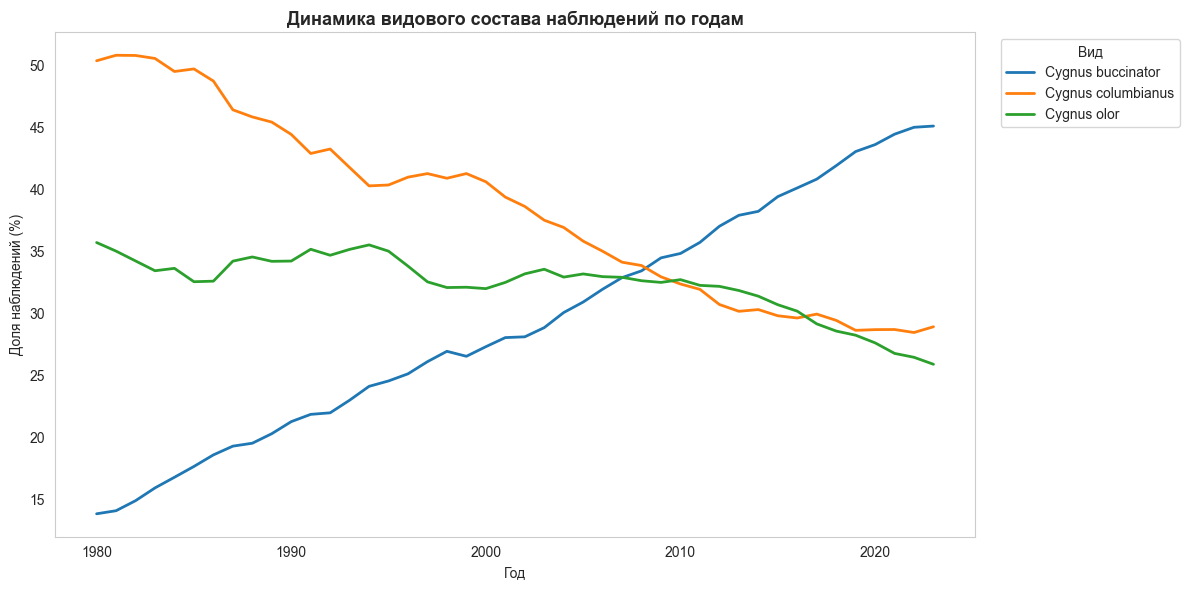

Доля C. olor: 34.5% (1980) → 24.2% (2023)


In [77]:
# Доля каждого вида по годам
species_by_year = (
    data_merged.groupby(['year', 'species'])['gbif_id']
    .count()
    .unstack(fill_value=0)
)
species_by_year_pct = species_by_year.div(species_by_year.sum(axis=1), axis=0) * 100

# Сглаживание скользящим средним (окно 5 лет) для наглядности
species_smooth = species_by_year_pct.rolling(5, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 6))
species_smooth.plot(ax=ax, linewidth=2)
ax.set_title('Динамика видового состава наблюдений по годам', fontsize=13, fontweight='bold')
ax.set_xlabel('Год')
ax.set_ylabel('Доля наблюдений (%)')
ax.legend(title='Вид', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Числа для отчёта: доля C. olor в начале и в конце периода
first_year = species_by_year_pct.index[0]
last_year = species_by_year_pct.index[-1]
print(f"Доля C. olor: {species_by_year_pct.loc[first_year, 'Cygnus olor']:.1f}% ({first_year}) → "
      f"{species_by_year_pct.loc[last_year, 'Cygnus olor']:.1f}% ({last_year})")

Первоначальная гипотеза о том, что смещение ареала на юг обусловлено ростом доли оседлого Cygnus olor, была опровергнута: доля этого вида в выборке снизилась с 34.5% до 24.2%.

Доля Cygnus buccinator значительно выросла (с 14% до 45%) за исследуемый период. 

## 23. Видоспецифичные тренды широты в Кластере 5 при гнездовании

Проверка, если в Кластере 5 при гнездовании: 

C. columbianus (мигрант) - широта стабильна,
C. olor (оседлый) - широта падает,

то экстремальный тренд порядка 1000 км за 43 года - артефакт данных. Если же все виды смещаются на юг - это реальный биологический сдвиг, и нашу гипотезу окончательно придётся пересмотреть.

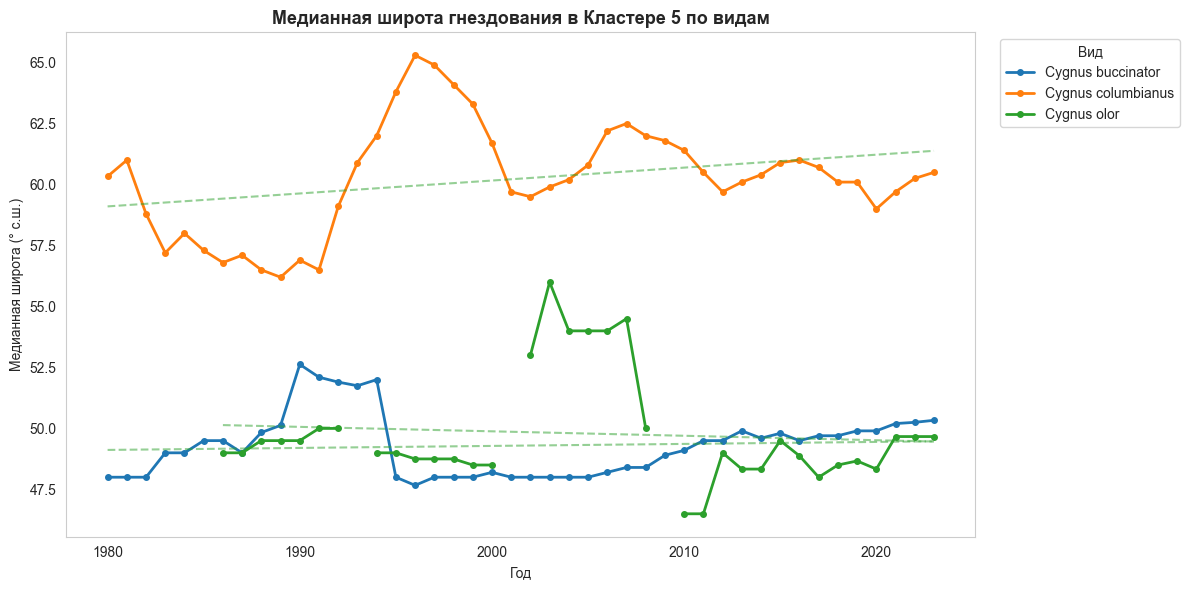

Наклоны тренда широты (град/год) в Кластере 5, гнездование:
  Cygnus buccinator: +0.00035 град/год (+2 км за 43 года)
  Cygnus columbianus: +0.04930 град/год (+235 км за 43 года)
  Cygnus olor: -0.03203 град/год (-153 км за 43 года)


In [78]:
# Фильтр: Кластер 5 + Гнездование
c5_breeding = data_merged[(data_merged['cluster'] == 5) & (data_merged['period_type'] == 2)].copy()

# Медианная широта по годам и видам
trend_by_species = (
    c5_breeding.groupby(['year', 'species'])['decimal_latitude']
    .median()
    .unstack()
)

# Сглаживание
trend_smooth = trend_by_species.rolling(5, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 6))
trend_smooth.plot(ax=ax, marker='o', linewidth=2, markersize=4)
ax.set_title('Медианная широта гнездования в Кластере 5 по видам', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Год')
ax.set_ylabel('Медианная широта (° с.ш.)')
ax.legend(title='Вид', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(alpha=0.3)

# Добавим линии тренда для наглядности
for species in trend_smooth.columns:
    valid = trend_smooth[species].dropna()
    if len(valid) > 5:
        coeffs = np.polyfit(valid.index, valid.values, 1)
        ax.plot(valid.index, coeffs[0]*valid.index + coeffs[1], 
                linestyle='--', alpha=0.5, color=ax.lines[-1].get_color())

plt.tight_layout()
plt.show()

# Числа: наклон тренда для каждого вида
print("Наклоны тренда широты (град/год) в Кластере 5, гнездование:")
for species in trend_by_species.columns:
    valid = trend_by_species[species].dropna()
    if len(valid) > 10:
        slope = np.polyfit(valid.index, valid.values, 1)[0]
        print(f"  {species}: {slope:+.5f} град/год ({slope*43*111:+.0f} км за 43 года)")

Ни один из мигрирующих видов на самом деле на юг не смещается. C. columbianus даже смещается на север.

Видоспецифичный анализ трендов широты гнездования в Кластере 5 окончательно разрешил природу наблюдаемого экстремального южного сдвига (-758...-1128 км за 43 года):

- Cygnus columbianus: широта гнездования стабильно растёт (+235 км за 43 года, тренд на север).
- Cygnus buccinator: широта гнездования стабильна (+2 км, тренд незначим).
- Cygnus olor: тренд ненадёжен из-за малого и прерывистого объёма выборки в данном кластере.

Вывод: Общий южный сдвиг Кластера 5 является чистым математическим артефактом изменения видового состава выборки. По мере того как доля арктического C. columbianus (гнездящегося на ~60° с.ш.) снижалась с 50% до 29%, а доля бореального C. buccinator (гнездящегося на ~49° с.ш.) росла с 14% до 45%, математический центроид наблюдений смещался на юг - при том что ни один из видов реально на юг не смещался.

Более того, выявленный тренд C. columbianus на север (+235 км) может указывать на реальный биологический процесс - смещение арктической границы гнездования в ответ на изменение климата. Этот сигнал был полностью скрыт в агрегированных данных и проявился только после раздельного анализа по видам.

In [79]:
# Перечисленные графики построены выше в соответствующих разделах

## 24. Выводы

> TODO: сформулируйте выводы в текстовом блоке:
> - наблюдается ли смещение ареала?
> - различается ли оно по кластерам?
> - какие различия между видами и сезонами?
> - какие ограничения анализа?

**Итоговые выводы по анализу пространственно-временной динамики ареала лебедей в Северной Америке:**


1. Наблюдается ли смещение ареала?

В данных наблюдается статистически значимое смещение широты наблюдений во времени, но оно зависит от сезона.

Для периода гнездования выявлен значимый тренд на смещение наблюдений к югу: коэффициент наклона составляет −0,05584° в год, что соответствует примерно −266,5 км за 43 года (p < 0,001).

Для зимовки статистически значимого общего тренда не выявлено (p = 0,1817). Оценённое изменение составляет около +21,7 км за 43 года, однако оно статистически не отличается от нулевого.

Таким образом, на уровне всей выборки можно говорить о южном временном тренде широты наблюдений в летний период, тогда как устойчивого общего тренда для зимнего периода не обнаружено.

При этом данный результат не следует напрямую интерпретировать как фактическое смещение биологического ареала птиц. Анализ показывает изменение географического распределения наблюдений, а не непосредственно изменение границ ареала популяции.

Дополнительный анализ видового состава показывает, что доля Cygnus columbianus снизилась примерно с 50% до 29%, а доля Cygnus buccinator выросла примерно с 14% до 45%. Поскольку эти виды имеют различающиеся широтные распределения, изменение их соотношения само по себе способно изменять общий центр распределения наблюдений.

После учёта вида и сезона коэффициент при year в регрессионной модели становится −0,0050, p = 0,060. Это означает, что в данной модели статистически значимый общий временной тренд на уровне 0,05 не выявлен, однако это не является доказательством полного отсутствия временного изменения.

2. Различается ли смещение по кластерам?

Да. Направление и величина тренда существенно различаются между кластерами и сезонами.

По бутстрап-оценкам 95% доверительных интервалов:

| Кластер | Зимовка | Гнездование |
|---|---|---|
| **1 — Западный и Центральный** | значимый сдвиг на юг: **−98.0…−27.6 км** | значимый сдвиг на юг: **−153.0…−69.8 км** |
| **2 — Восточный** | значимый сдвиг на юг: **−169.5…−101.4 км** | значимый сдвиг на юг: **−243.4…−139.1 км** |
| **3 — Крайний Север** | значимый сдвиг на север: **+1.6…+304.4 км** *(за 32 года)* | тренд незначим: **−98.9…+54.4 км** |
| **4 — Субарктика** | значимый сдвиг на север: **+73.5…+197.4 км** | значимый сдвиг на юг: **−612.2…−286.1 км** |
| **5 — Арктика/Восток** | тренд незначим: **−391.3…+38.2 км** | значимый сдвиг на юг: **−1138.0…−744.8 км** |

Таким образом, единой пространственной динамики для всех кластеров нет.

Кластеры 1 и 2 демонстрируют статистически значимый южный тренд и зимой, и летом. В Кластере 3 статистически значимых изменений ни в одном из сезонов не выявлено. Кластер 4 отличается противоположными направлениями: зимой наблюдается значимый сдвиг на север, а летом - на юг. В Кластере 5 зимний тренд статистически незначим, тогда как для летнего периода выявлен наиболее сильный южный тренд.

Особенно важно, что экстремальный южный тренд Кластера 5 не следует трактовать как доказательство реального перемещения ареала примерно на 1000 км. Видоспецифичный анализ показывает, что C. columbianus в этом кластере имеет положительный оценённый тренд (около +235 км за 43 года), а C. buccinator - практически нулевой (около +2 км). Поэтому общий тренд Кластера 5 может в значительной степени формироваться изменением соотношения видов в выборке. При этом статистическая значимость отдельных видоспецифичных трендов в этом анализе отдельно не оценивалась, поэтому делать окончательный вывод о реальном биологическом сдвиге для конкретного вида нельзя.

3. Какие различия между видами и сезонами?

Непараметрический тест Краскела–Уоллиса подтвердил статистически значимые различия между тремя видами как по широте (H = 4528,09, p < 0,001), так и по температуре (H = 1501,91, p < 0,001). Попарные сравнения Манна–Уитни с поправкой Бонферрони подтвердили статистическую значимость различий для всех пар видов по обоим показателям (p < 0,001).

- Cygnus columbianus характеризуется наиболее холодным распределением наблюдений: медианная температура составляет около 2–3 °C. Вид достигает наиболее высоких широт - примерно 65° с.ш. и выше.
- Cygnus buccinator занимает промежуточное положение по широте: медианная широта около 45° с.ш., медианная температура - около 9 °C. Наблюдения охватывают широкий диапазон примерно от 30 до 62° с.ш.
- Cygnus olor имеет наиболее низкую медианную широту - около 41° с.ш., при медианной температуре около 9 °C. Основная часть наблюдений находится примерно в диапазоне 31–50° с.ш.

Таким образом, в имеющейся выборке виды имеют статистически различающиеся распределения широты и температуры, при этом их распределения не являются полностью раздельными.

По сезонам тест Манна–Уитни также выявил статистически значимые различия (U = 72 489 238, p < 0,001). Медианная широта наблюдений составляет 45° с.ш. для периода гнездования и 42° с.ш. для зимовки. Следовательно, летние наблюдения в совокупности расположены примерно на 3° севернее зимних.

При этом эти результаты характеризуют различия между группами сезонных наблюдений, а не отслеживание перемещений одних и тех же особей. Поэтому корректнее говорить о различии географического распределения наблюдений между сезонами, а не непосредственно измерять по этим данным расстояние миграции.

4. Ограничения анализа

1. Обязательная дедупликация существенно сокращает исходную выборку.
Согласно ТЗ, наблюдения дедуплицируются по комбинации год + сезон + округлённые координаты + вид. В результате из исходных миллионов записей формируется существенно меньшая аналитическая выборка. Такая процедура необходима для выполнения ТЗ, но она означает, что итоговые результаты характеризуют дедуплицированную выборку, а не исходное количество наблюдений. Кроме того, при одинаковом годе, сезоне, виде и округлённых координатах несколько исходных записей заменяются одной. Это необходимо учитывать при интерпретации распределений и статистических тестов.

2. Сезон является приближённым показателем.
В анализе «зимовка» определяется месяцами декабрь–февраль, а «гнездование» - июнь–август. Поэтому результаты относятся к зимнему и летнему периодам наблюдений, а не непосредственно к подтверждённым местам зимовки и гнездования.

3. Данные не являются случайной выборкой популяции.
Распределение наблюдений может зависеть от интенсивности наблюдений, доступности территорий и структуры источников данных. Поэтому изменение географии наблюдений во времени не обязательно означает изменение фактического ареала.

4. Количество наблюдений не равно численности птиц.
Одна запись может соответствовать одному наблюдению или большой группе птиц. Поэтому по этим данным нельзя делать выводы об изменении абсолютной численности популяций.

5. Покрытие данных неравномерно во времени и пространстве.
Около 70% данных относятся к периоду после 2007 года, тогда как ранние годы представлены значительно слабее. Арктические кластеры также существенно уступают кластерам умеренных широт по объёму наблюдений.

6. Для отдельных кластеров объём данных невелик.
Особенно это относится к зимним наблюдениям в Кластерах 3 (n = 158) и 5 (n = 90). Для них доверительные интервалы широкие, и статистически значимый тренд не подтверждён.

7. Observer bias остаётся гипотезой, а не доказанным механизмом.
Изменение видового состава действительно обнаружено: доля C. columbianus снизилась примерно с 50% до 29%, C. buccinator выросла примерно с 14% до 45%, а C. olor снизилась с 34,5% до 24,2%. Это поддерживает объяснение части агрегированного тренда изменением структуры выборки. Однако в рамках текущего анализа источник наблюдения и его изменение во времени непосредственно не моделируются, поэтому полностью отделить observer bias от реального биологического изменения нельзя.

8. Нельзя однозначно считать северный тренд Кластера 4 доказательством климатического сдвига.
В Кластере 4 зимний тренд статистически значимо направлен на север (+69…+202 км по 95% ДИ), но этот результат показывает изменение распределения наблюдений. Гипотеза о связи с изменением климата является возможной интерпретацией, но непосредственно причинная связь в данном анализе не установлена.

9. Не следует делать вывод об отсутствии биологического изменения только на основании p = 0,060.
После учёта вида и сезона общий коэффициент года становится статистически незначимым на уровне 0,05. Это означает отсутствие статистически подтверждённого общего линейного тренда в данной модели, но не доказывает, что биологического изменения нет.

9. Для окончательного разделения реального изменения ареала и изменения структуры наблюдений необходим независимый контрольный анализ.
Текущий набор данных позволяет выявить пространственно-временные закономерности и показать, где они наиболее выражены, но не позволяет окончательно установить их биологическую причину.

Итоговый вывод

В данных обнаружено статистически значимое южное смещение широты наблюдений в летний период, тогда как общего значимого тренда для зимнего периода не выявлено. Характер динамики существенно различается между кластерами: в одних регионах наблюдается южный сдвиг, в других - отсутствие значимого тренда, а в Кластере 4 зимой выявлен северный сдвиг.

При этом результаты не дают оснований напрямую называть эти изменения смещением биологического ареала. Существенное изменение видового состава наблюдений, особенно снижение доли C. columbianus и рост доли C. buccinator, показывает, что часть агрегированного временного тренда может быть связана с изменением структуры выборки. Поэтому наиболее корректный вывод исследования - выявлено изменение пространственного распределения наблюдений во времени, но его биологическую природу по имеющимся данным однозначно установить нельзя.